In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv
/kaggle/input/conv-out/conv1_out.bin


In [2]:
import numpy as np
import pandas as pd
from scipy import signal
from scipy.signal import butter, filtfilt, iirnotch

df=pd.read_csv('/kaggle/input/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv')

In [3]:
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
df.drop(columns=['Unnamed'], inplace=True)

In [5]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='object', length=179)

In [6]:
feature_cols = [c for c in df.columns if c.startswith('X')]
X_raw = df[feature_cols].to_numpy(dtype=float)   
y_raw = df['y'].to_numpy()

In [7]:
X_raw.shape

(11500, 178)

In [8]:
y_raw.shape

(11500,)

In [9]:
fs = 178.0
nyq = fs / 2.0

# Detrend helper
def detrend_seg(x):
    return signal.detrend(x, type='constant')

#  Notch filter 
def design_notch(freq_hz, fs, Q=30.0):
    w0 = freq_hz / (fs/2.0)
    b, a = iirnotch(w0, Q)
    return b, a

In [10]:
fs = 178.0
nyq = fs / 2.0

# ---- Robust designers ----
def design_bandpass(low_hz, high_hz, fs, order=4, safety=0.99):
    nyq = fs / 2.0
    # keep within (0, nyq)
    low = max(1e-6, min(low_hz, nyq * safety))
    high = max(low + 1e-6, min(high_hz, nyq * safety))
    # normalize
    Wn = [low/nyq, high/nyq]
    return butter(order, Wn, btype='band')

def design_notch(mains_hz, fs, Q=30.0):
    # use Hz-based API to avoid normalization confusion
    return iirnotch(w0=mains_hz, Q=Q, fs=fs)

# Paper says 2.87–100 Hz; at fs=178 we must cap highcut < 89.
lowcut = 2.87
highcut = 85.0        # safe upper cut (you can use 80–85)
b_bp, a_bp = design_bandpass(lowcut, highcut, fs, order=4)

USE_NOTCH = False      # set True if needed
if USE_NOTCH:
    b_notch, a_notch = design_notch(50.0, fs, Q=30.0)  # or 60.0

def preprocess_segment(x):
    x = signal.detrend(x, type='constant')                 # optional but safe
    if USE_NOTCH:
        x = filtfilt(b_notch, a_notch, x, method="pad")    # notch hum
    x = filtfilt(b_bp, a_bp, x, method="pad")              # band-pass
    # per-window Z-score 
    mu, sd = np.mean(x), np.std(x)
    return (x - mu) / sd if sd > 1e-8 else (x - mu)


In [11]:
X_proc = np.apply_along_axis(preprocess_segment, 1, X_raw)
X_proc_cnn = X_proc[..., np.newaxis]
y_binary = (y_raw == 1).astype(int)
print(X_proc.shape, X_proc_cnn.shape, y_binary.shape)

(11500, 178) (11500, 178, 1) (11500,)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Binary target: seizure (1) vs non-seizure (0)
y = y_binary
X = X_proc_cnn  # shape (N, 178, 1)

# Train/Val/Test split (60/20/20), stratified
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)  

# Optional: class weights to handle imbalance
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weights)

Class weights: {0: 0.625, 1: 2.5}


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
tf.keras.backend.clear_session()

2025-11-13 22:05:31.959416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763071532.196781      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763071532.264928      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [14]:
input_len = X_proc_cnn.shape[1]
model=models.Sequential()

# Input layer
model.add(layers.Input(shape=(input_len,1), name="input"))
# conv1
model.add(layers.Conv1D(filters=8, kernel_size=5, strides=1, padding="same",use_bias=True, activation=None, name="conv1"))
# Relu1
model.add(layers.ReLU(name="relu1"))
# maxpool1
model.add(layers.MaxPooling1D(pool_size=2, strides=2, padding="valid", name="pool1"))
# conv2
model.add(layers.Conv1D(filters=12, kernel_size=3, strides=1, padding="same",use_bias=True, activation=None, name="conv2"))
# relu2
model.add(layers.ReLU(name="relu2"))
# maxpool2
model.add(layers.MaxPooling1D(pool_size=2, strides=2, padding="valid", name="pool2"))
# fc1
model.add(layers.Flatten(name="flatten"))
model.add(layers.Dense(32, activation="relu", name="fc1"))
# fc2
model.add(layers.Dense(16, activation="relu", name="fc2"))
# fc3
model.add(layers.Dense(8, activation="relu", name="fc3"))
# output layer
model.add(layers.Dense(2, activation="softmax", name="softmax"))
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.summary()


2025-11-13 22:05:46.457983: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 178, 8)         │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 178, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 89, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 89, 12)         │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 89, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 44, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 528)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │        16,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,958 (70.15 KB)

 Trainable params: 17,958 (70.15 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
input_len

178

In [16]:
early = callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss")
reduce = callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, monitor="val_loss")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,
    class_weight=class_weights,  
    callbacks=[early, reduce],
    verbose=1
)

proba_test = model.predict(X_test)
y_pred = proba_test.argmax(axis=1)


Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7194 - loss: 0.6645 - val_accuracy: 0.8326 - val_loss: 0.4660 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7935 - loss: 0.4956 - val_accuracy: 0.8352 - val_loss: 0.4124 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8542 - loss: 0.3650 - val_accuracy: 0.8591 - val_loss: 0.3468 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8819 - loss: 0.3041 - val_accuracy: 0.8691 - val_loss: 0.3405 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9066 - loss: 0.2407 - val_accuracy: 0.9074 - val_loss: 0.2502 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9170 - loss: 0.2126 - val_accuracy: 0.9274 - val_loss: 0.2181 - learning_rate: 0.0010
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9396 - loss: 0

In [17]:
# Predict single sample
yp = model.predict(X_train[0:1], verbose=0)

print("Prediction shape:", yp.shape)
print("Prediction:", yp)

# Get class and probability
y_class = np.argmax(yp, axis=1)
y_prob = np.max(yp, axis=1)

print(f"Predicted class: {y_class[0]}")
print(f"Confidence/Probability: {y_prob[0]:.4f}")

# Print all class probabilities
print("\nClass Probabilities:")
for class_idx in range(yp.shape[1]):
    print(f"  Class {class_idx}: {yp[0, class_idx]:.6f}")


Prediction shape: (1, 2)
Prediction: [[9.999943e-01 5.718042e-06]]
Predicted class: 0
Confidence/Probability: 1.0000

Class Probabilities:
  Class 0: 0.999994
  Class 1: 0.000006


In [18]:
# --- Accuracies on train/val/test ---
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print(f"Train  accuracy: {train_acc:.4f}")
print(f"Val    accuracy: {val_acc:.4f}")
print(f"Test   accuracy: {test_acc:.4f}")


Train  accuracy: 0.9857
Val    accuracy: 0.9478
Test   accuracy: 0.9374


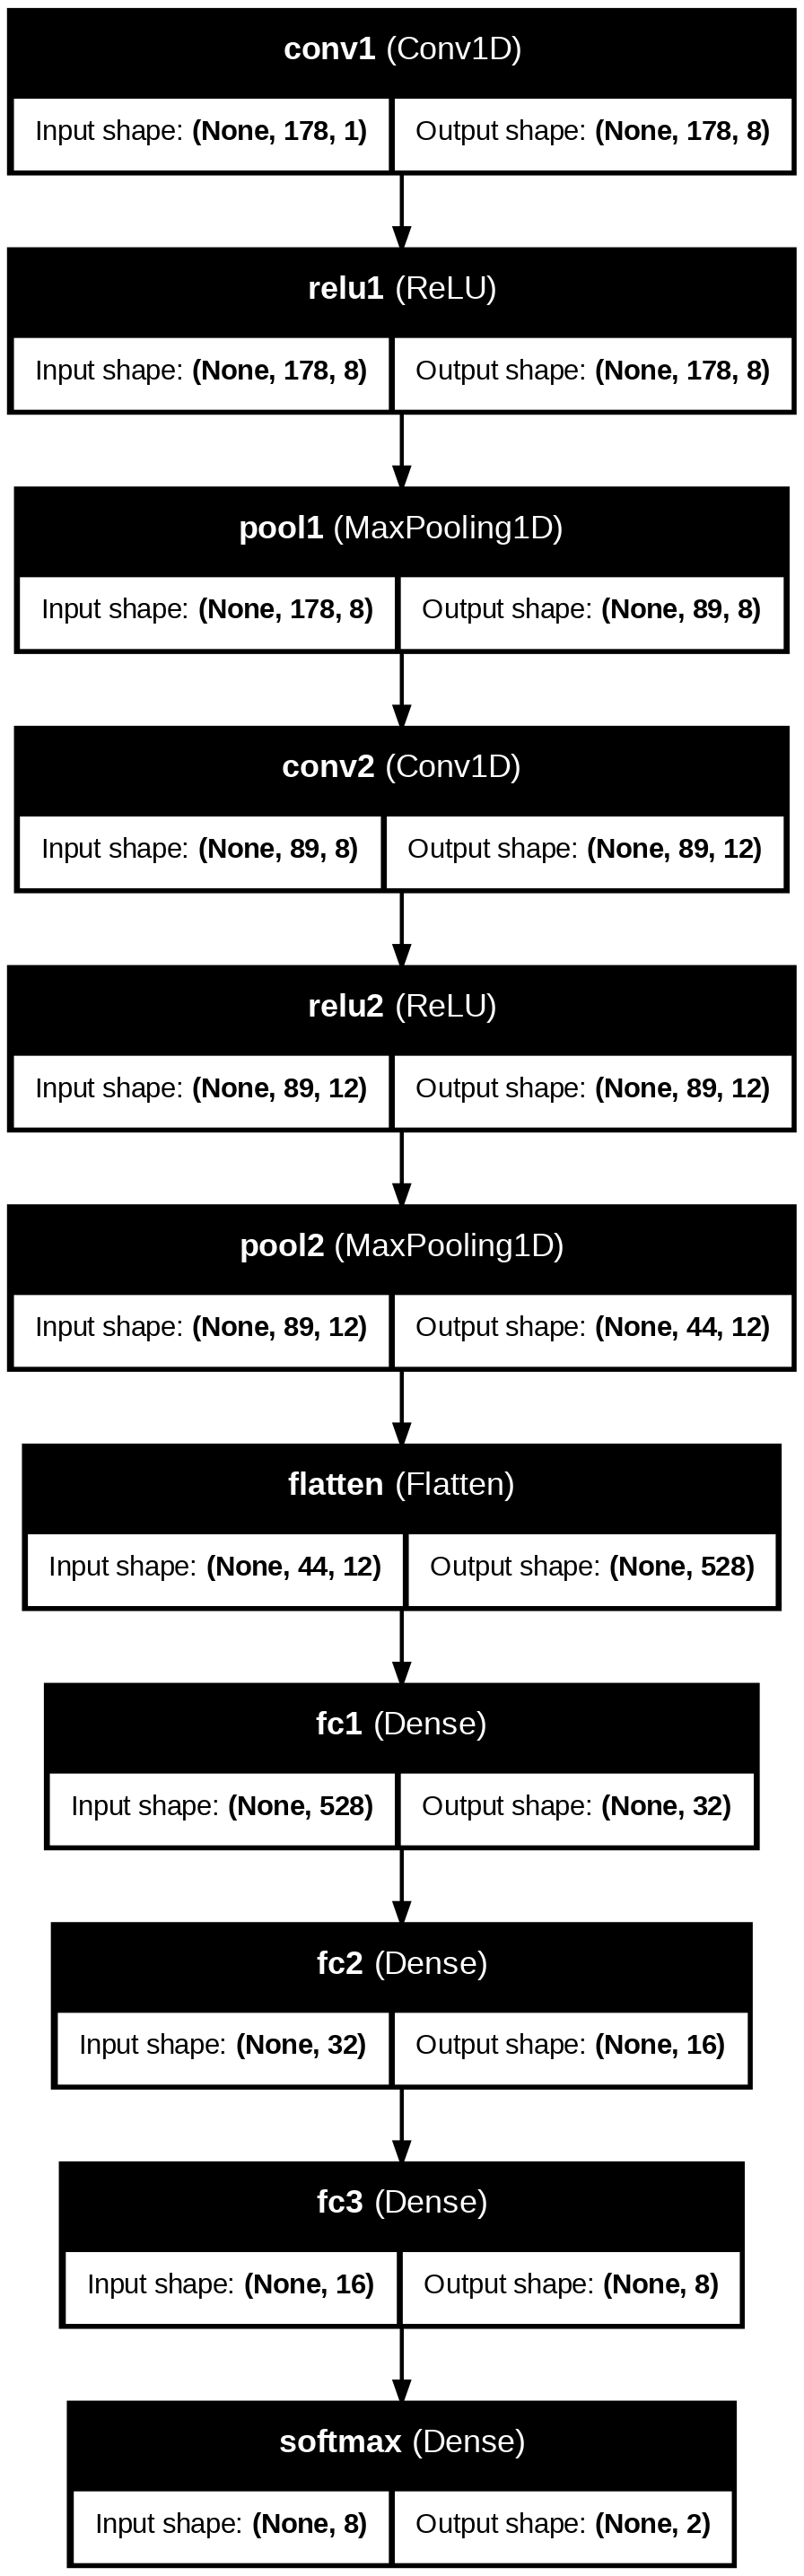

In [ ]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# Save and display
plot_model(
    model,
    to_file="model_architecture.png",
    show_shapes=True,          # show tensor shapes
    show_layer_names=True,
    expand_nested=True,
    dpi=160
)
display(Image("model_architecture.png"))


In [ ]:
import os
os.makedirs("weights", exist_ok=True)   # create folder if missing
model.save_weights("weights/cnn_weights.weights.h5")

In [ ]:
model.load_weights("/kaggle/working/weights/cnn_weights.weights.h5")

# 3) Print a compact summary of each layer’s weights
import numpy as np

def describe(arr, name):
    print(f"{name:18s} shape={arr.shape}  "
          f"min={arr.min():.4g} max={arr.max():.4g} "
          f"mean={arr.mean():.4g} std={arr.std():.4g}")

for layer in model.layers:
    params = layer.get_weights()  # list: [kernel, bias] for Dense/Conv, etc.
    if not params:
        continue
    for i, w in enumerate(params):
        describe(w, f"{layer.name}/W{i}")

conv1/W0           shape=(5, 1, 8)  min=-0.3993 max=0.4707 mean=0.001641 std=0.2339
conv1/W1           shape=(8,)  min=-0.1475 max=0.125 mean=-0.0008487 std=0.08465
conv2/W0           shape=(3, 8, 12)  min=-0.4372 max=0.4735 mean=0.02836 std=0.2025
conv2/W1           shape=(12,)  min=-0.223 max=0.07117 mean=-0.03121 std=0.07801
fc1/W0             shape=(528, 32)  min=-0.3152 max=0.3185 mean=0.002765 std=0.08018
fc1/W1             shape=(32,)  min=-0.01866 max=0.08118 mean=0.01311 std=0.02042
fc2/W0             shape=(32, 16)  min=-0.5759 max=0.5574 mean=0.02644 std=0.2543
fc2/W1             shape=(16,)  min=-0.0199 max=0.05632 mean=0.006325 std=0.01762
fc3/W0             shape=(16, 8)  min=-0.7156 max=0.7398 mean=0.00839 std=0.345
fc3/W1             shape=(8,)  min=-0.0254 max=0.03973 mean=0.007576 std=0.02146
softmax/W0         shape=(8, 2)  min=-0.8052 max=0.7327 mean=0.06005 std=0.4989
softmax/W1         shape=(2,)  min=-0.02322 max=0.02322 mean=6.519e-09 std=0.02322


In [ ]:
# Get weights and bias from conv1
weights, bias = model.get_layer("conv1").get_weights()
print("conv1 Weights shape:", weights.shape)
print("conv1 Bias shape:", bias.shape)
print("conv1 Weights:\n", weights)
print("conv1 Bias:\n", bias)

conv1 Weights shape: (5, 1, 8)
conv1 Bias shape: (8,)
conv1 Weights:
 [[[-0.0171256  -0.18094952 -0.37990242 -0.05342755  0.33075264
    0.02016052  0.1291566  -0.3679612 ]]

 [[ 0.10842052 -0.0718966  -0.10440513 -0.05869905  0.40536907
    0.1045111   0.38843358 -0.06835496]]

 [[ 0.11809343  0.14710815  0.41649756  0.10090052  0.03912238
   -0.07813768 -0.02647386  0.47067508]]

 [[ 0.06587721 -0.24511622  0.20820448  0.22169256 -0.39925456
   -0.09523264 -0.35522664  0.14185557]]

 [[-0.13403311 -0.20692298  0.00533413 -0.20206733 -0.3494632
   -0.14536668  0.4095806  -0.22610407]]]
conv1 Bias:
 [ 0.00868544 -0.12021846  0.02788864  0.02591649  0.01149749 -0.14750804
  0.12501696  0.06193171]


In [ ]:
import numpy as np

def quantize_layer_int8_int32(model, layer_name):
    """Quantize weights to int8 and bias to int32"""
    layer = model.get_layer(layer_name)
    weights, bias = layer.get_weights()
    
    # ===== Quantize Weights to int8 =====
    weight_min = np.min(weights)
    weight_max = np.max(weights)
    weight_scale = (weight_max - weight_min) / 255.0
    weight_zero_point = -np.round(weight_min / weight_scale).astype(int)
    
    weights_int8 = np.round((weights / weight_scale) + weight_zero_point).astype(np.int8)
    
    # ===== Quantize Bias to int32 =====
    # Bias should be: bias_int32 = bias * input_scale * weight_scale
    # For simplicity, just round to int32
    bias_int32 = np.round(bias).astype(np.int32)
    
    print(f"\n{layer_name}:")
    print(f"  Weights - Original shape: {weights.shape}, Original range: [{weight_min:.4f}, {weight_max:.4f}]")
    print(f"  Weights - Quantized to int8, shape: {weights_int8.shape}")
    print(f"  Weights - Scale: {weight_scale}, Zero Point: {weight_zero_point}")
    print(f"  Bias - Original shape: {bias.shape}, Original range: [{np.min(bias):.6f}, {np.max(bias):.6f}]")
    print(f"  Bias - Quantized to int32, shape: {bias_int32.shape}")
    print(f"  Weights sample: {weights_int8[0, 0, :]}")
    print(f"  Bias sample: {bias_int32}")
    
    return weights_int8, bias_int32, weight_scale, weight_zero_point

def quantize_dense_layer_int8_int32(model, layer_name):
    """Quantize Dense (fully connected) layer weights to int8 and bias to int32"""
    layer = model.get_layer(layer_name)
    weights, bias = layer.get_weights()
    
    # ===== Quantize Weights to int8 =====
    weight_min = np.min(weights)
    weight_max = np.max(weights)
    weight_scale = (weight_max - weight_min) / 255.0
    weight_zero_point = -np.round(weight_min / weight_scale).astype(int)
    
    weights_int8 = np.round((weights / weight_scale) + weight_zero_point).astype(np.int8)
    
    # ===== Quantize Bias to int32 =====
    bias_int32 = np.round(bias).astype(np.int32)
    
    print(f"\n{layer_name} (Dense):")
    print(f"  Weights - Original shape: {weights.shape} (input_units={weights.shape[0]}, output_units={weights.shape[1]})")
    print(f"  Weights - Original range: [{weight_min:.4f}, {weight_max:.4f}]")
    print(f"  Weights - Quantized to int8")
    print(f"  Weights - Scale: {weight_scale:.6f}, Zero Point: {weight_zero_point}")
    print(f"  Bias - Original shape: {bias.shape}")
    print(f"  Bias - Original range: [{np.min(bias):.6f}, {np.max(bias):.6f}]")
    print(f"  Bias - Quantized to int32")
    print(f"  Weights sample (first 5): {weights_int8.flatten()[:5]}")
    print(f"  Bias sample: {bias_int32}")
    
    return weights_int8, bias_int32, weight_scale, weight_zero_point


# # Quantize all Conv1D layers
# for layer in model.layers:
#     if isinstance(layer, tf.keras.layers.Conv1D):
#         w_q, b_q, scale, zp = quantize_layer_int8_int32(model, layer.name)

In [ ]:
quantization_params = {}

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv1D):
        w_q, b_q, scale, zp = quantize_layer_int8_int32(model, layer.name)
        quantization_params[layer.name] = {
            'weights_int8': w_q,
            'bias_int32': b_q,
            'weight_scale': scale,
            'weight_zero_point': zp,
            'type': 'Conv1D'
        }
    
    elif isinstance(layer, tf.keras.layers.Dense):
        w_q, b_q, scale, zp = quantize_dense_layer_int8_int32(model, layer.name)
        quantization_params[layer.name] = {
            'weights_int8': w_q,
            'bias_int32': b_q,
            'weight_scale': scale,
            'weight_zero_point': zp,
            'type': 'Dense'
        }


conv1:
  Weights - Original shape: (5, 1, 8), Original range: [-0.3993, 0.4707]
  Weights - Quantized to int8, shape: (5, 1, 8)
  Weights - Scale: 0.0034114889070099475, Zero Point: 117
  Bias - Original shape: (8,), Original range: [-0.147508, 0.125017]
  Bias - Quantized to int32, shape: (8,)
  Weights sample: [ 112   64    6  101  -42  123 -101    9]
  Bias sample: [0 0 0 0 0 0 0 0]

conv2:
  Weights - Original shape: (3, 8, 12), Original range: [-0.4372, 0.4735]
  Weights - Quantized to int8, shape: (3, 8, 12)
  Weights - Scale: 0.0035710984585331936, Zero Point: 122
  Bias - Original shape: (12,), Original range: [-0.222975, 0.071166]
  Bias - Quantized to int32, shape: (12,)
  Weights sample: [  63   73  107  -60   69  -58 -121   72   90 -105   64 -111]
  Bias sample: [0 0 0 0 0 0 0 0 0 0 0 0]

fc1 (Dense):
  Weights - Original shape: (528, 32) (input_units=528, output_units=32)
  Weights - Original range: [-0.3152, 0.3185]
  Weights - Quantized to int8
  Weights - Scale: 0.0024

In [ ]:
def quantize_layer_int8_int32(model, layer_name):
    """Quantize weights to int8 and bias to int32 for Conv1D and Dense layers"""
    layer = model.get_layer(layer_name)
    weights, bias = layer.get_weights()
    
    # ===== Quantize Weights to int8 =====
    weight_min = np.min(weights)
    weight_max = np.max(weights)
    weight_scale = (weight_max - weight_min) / 255.0
    weight_zero_point = -np.round(weight_min / weight_scale).astype(int)
    
    weights_int8 = np.round((weights / weight_scale) + weight_zero_point).astype(np.int8)
    
    # ===== Quantize Bias to int32 =====
    bias_int32 = np.round(bias).astype(np.int32)
    
    print(f"\n{layer_name} ({layer.__class__.__name__}):")
    print(f"  Weights - Original shape: {weights.shape}, Range: [{weight_min:.4f}, {weight_max:.4f}]")
    print(f"  Weights - Quantized to int8, shape: {weights_int8.shape}")
    print(f"  Weights - Scale: {weight_scale:.6f}, Zero Point: {weight_zero_point}")
    print(f"  Bias - Original shape: {bias.shape}, Range: [{np.min(bias):.6f}, {np.max(bias):.6f}]")
    print(f"  Bias - Quantized to int32, shape: {bias_int32.shape}")
    print(f"  Weights sample: {weights_int8.flatten()[:5]}")
    print(f"  Bias sample: {bias_int32}")
    
    return weights_int8, bias_int32, weight_scale, weight_zero_point



    """Quantize Dense (fully connected) layer weights to int8 and bias to int32"""
    layer = model.get_layer(layer_name)
    weights, bias = layer.get_weights()
    
    # ===== Quantize Weights to int8 =====
    weight_min = np.min(weights)
    weight_max = np.max(weights)
    weight_scale = (weight_max - weight_min) / 255.0
    weight_zero_point = -np.round(weight_min / weight_scale).astype(int)
    
    weights_int8 = np.round((weights / weight_scale) + weight_zero_point).astype(np.int8)
    
    # ===== Quantize Bias to int32 =====
    bias_int32 = np.round(bias).astype(np.int32)
    
    print(f"\n{layer_name} (Dense):")
    print(f"  Weights - Original shape: {weights.shape} (input_units={weights.shape[0]}, output_units={weights.shape[1]})")
    print(f"  Weights - Original range: [{weight_min:.4f}, {weight_max:.4f}]")
    print(f"  Weights - Quantized to int8")
    print(f"  Weights - Scale: {weight_scale:.6f}, Zero Point: {weight_zero_point}")
    print(f"  Bias - Original shape: {bias.shape}")
    print(f"  Bias - Original range: [{np.min(bias):.6f}, {np.max(bias):.6f}]")
    print(f"  Bias - Quantized to int32")
    print(f"  Weights sample (first 5): {weights_int8.flatten()[:5]}")
    print(f"  Bias sample: {bias_int32}")
    
    return weights_int8, bias_int32, weight_scale, weight_zero_point



In [ ]:
quantization_params2 = {}

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv1D):
        w_q, b_q, scale, zp = quantize_layer_int8_int32(model, layer.name)
        quantization_params2[layer.name] = {
            'weights_int8': w_q,
            'bias_int32': b_q,
            'weight_scale': scale,
            'weight_zero_point': zp,
            'type': 'Conv1D'
        }
    
    elif isinstance(layer, tf.keras.layers.Dense):
        w_q, b_q, scale, zp = quantize_dense_layer_int8_int32(model, layer.name)
        quantization_params2[layer.name] = {
            'weights_int8': w_q,
            'bias_int32': b_q,
            'weight_scale': scale,
            'weight_zero_point': zp,
            'type': 'Dense'
        }
        
        # Check if Dense layer has Softmax activation
        if layer.activation == tf.keras.activations.softmax:
            print(f"  [INFO] {layer.name} has Softmax activation applied")
            print(f"  Output will be in range [0, 1] after Softmax")



conv1 (Conv1D):
  Weights - Original shape: (5, 1, 8), Range: [-0.3993, 0.4707]
  Weights - Quantized to int8, shape: (5, 1, 8)
  Weights - Scale: 0.003411, Zero Point: 117
  Bias - Original shape: (8,), Range: [-0.147508, 0.125017]
  Bias - Quantized to int32, shape: (8,)
  Weights sample: [112  64   6 101 -42]
  Bias sample: [0 0 0 0 0 0 0 0]

conv2 (Conv1D):
  Weights - Original shape: (3, 8, 12), Range: [-0.4372, 0.4735]
  Weights - Quantized to int8, shape: (3, 8, 12)
  Weights - Scale: 0.003571, Zero Point: 122
  Bias - Original shape: (12,), Range: [-0.222975, 0.071166]
  Bias - Quantized to int32, shape: (12,)
  Weights sample: [ 63  73 107 -60  69]
  Bias sample: [0 0 0 0 0 0 0 0 0 0 0 0]

fc1 (Dense):
  Weights - Original shape: (528, 32) (input_units=528, output_units=32)
  Weights - Original range: [-0.3152, 0.3185]
  Weights - Quantized to int8
  Weights - Scale: 0.002485, Zero Point: 127
  Bias - Original shape: (32,)
  Bias - Original range: [-0.018662, 0.081179]
  Bias

In [27]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def dequantize_int8_int32(weights_int8, bias_int32, weight_scale, weight_zero_point):
    """Dequantize int8 weights and int32 bias back to float32"""
    weights_float = (weights_int8.astype(np.float32) - weight_zero_point) * weight_scale
    bias_float = bias_int32.astype(np.float32)
    return weights_float, bias_float


def create_quantized_model(model, quantization_params):
    """
    Create a copy of the model with quantized weights
    Returns the model with quantized weights
    """
    quantized_model = tf.keras.models.clone_model(model)
    
    for layer_name, params in quantization_params.items():
        layer = quantized_model.get_layer(layer_name)
        
        if params['type'] in ['Conv1D', 'Dense']:
            # Dequantize back to float32 for inference
            weights_float, bias_float = dequantize_int8_int32(
                params['weights_int8'],
                params['bias_int32'],
                params['weight_scale'],
                params['weight_zero_point']
            )
            
            # Set the dequantized weights
            layer.set_weights([weights_float, bias_float])
            print(f"✓ Set quantized weights for {layer_name}")
    
    return quantized_model


def evaluate_quantized_model(original_model, quantized_model, X_test, y_test):
    """
    Evaluate and compare original vs quantized model
    """
    print("\n" + "=" * 70)
    print("QUANTIZED MODEL ACCURACY EVALUATION")
    print("=" * 70)
    
    # Predictions with original model
    y_pred_original = original_model.predict(X_test, verbose=0)
    y_pred_original_class = np.argmax(y_pred_original, axis=1)
    
    # Predictions with quantized model
    y_pred_quantized = quantized_model.predict(X_test, verbose=0)
    y_pred_quantized_class = np.argmax(y_pred_quantized, axis=1)
    
    # Flatten y_test if needed
    y_test_flat = y_test.flatten() if len(y_test.shape) > 1 else y_test
    
    # Calculate metrics for original model
    acc_original = accuracy_score(y_test_flat, y_pred_original_class)
    precision_original = precision_score(y_test_flat, y_pred_original_class, zero_division=0)
    recall_original = recall_score(y_test_flat, y_pred_original_class, zero_division=0)
    f1_original = f1_score(y_test_flat, y_pred_original_class, zero_division=0)
    
    # Calculate metrics for quantized model
    acc_quantized = accuracy_score(y_test_flat, y_pred_quantized_class)
    precision_quantized = precision_score(y_test_flat, y_pred_quantized_class, zero_division=0)
    recall_quantized = recall_score(y_test_flat, y_pred_quantized_class, zero_division=0)
    f1_quantized = f1_score(y_test_flat, y_pred_quantized_class, zero_division=0)
    
    # Calculate accuracy loss
    accuracy_drop = (acc_original - acc_quantized) * 100
    
    print(f"\n{'Metric':<20} {'Original':<15} {'Quantized':<15} {'Difference':<15}")
    print("-" * 65)
    print(f"{'Accuracy':<20} {acc_original:<15.4f} {acc_quantized:<15.4f} {accuracy_drop:<15.4f}%")
    print(f"{'Precision':<20} {precision_original:<15.4f} {precision_quantized:<15.4f} {(precision_original-precision_quantized):<15.4f}")
    print(f"{'Recall':<20} {recall_original:<15.4f} {recall_quantized:<15.4f} {(recall_original-recall_quantized):<15.4f}")
    print(f"{'F1-Score':<20} {f1_original:<15.4f} {f1_quantized:<15.4f} {(f1_original-f1_quantized):<15.4f}")
    
    print("\n" + "-" * 65)
    if accuracy_drop <= 1.0:
        print(f"✓ Accuracy drop is acceptable: {accuracy_drop:.2f}%")
    else:
        print(f"⚠ Accuracy drop is significant: {accuracy_drop:.2f}%")
    
    # Confusion matrices
    print("\n" + "=" * 70)
    print("CONFUSION MATRICES")
    print("=" * 70)
    
    cm_original = confusion_matrix(y_test_flat, y_pred_original_class)
    cm_quantized = confusion_matrix(y_test_flat, y_pred_quantized_class)
    
    print("\nOriginal Model Confusion Matrix:")
    print(cm_original)
    
    print("\nQuantized Model Confusion Matrix:")
    print(cm_quantized)
    
    print("\nDifference in Confusion Matrix (Quantized - Original):")
    print(cm_quantized - cm_original)
    
    # Per-class accuracy
    print("\n" + "=" * 70)
    print("PER-CLASS ACCURACY")
    print("=" * 70)
    
    cm_original_normalized = cm_original.astype('float') / cm_original.sum(axis=1)[:, np.newaxis]
    cm_quantized_normalized = cm_quantized.astype('float') / cm_quantized.sum(axis=1)[:, np.newaxis]
    
    print(f"\n{'Class':<10} {'Original Recall':<20} {'Quantized Recall':<20} {'Difference':<15}")
    print("-" * 65)
    for i in range(cm_original_normalized.shape[0]):
        orig_recall = cm_original_normalized[i, i]
        quant_recall = cm_quantized_normalized[i, i]
        diff = orig_recall - quant_recall
        print(f"Class {i:<5} {orig_recall:<20.4f} {quant_recall:<20.4f} {diff:<15.4f}")
    
    return {
        'original_accuracy': acc_original,
        'quantized_accuracy': acc_quantized,
        'accuracy_drop': accuracy_drop,
        'original_predictions': y_pred_original_class,
        'quantized_predictions': y_pred_quantized_class,
        'confusion_matrix_original': cm_original,
        'confusion_matrix_quantized': cm_quantized
    }


# ===== USAGE =====
# Assuming you have:
# - model: original trained model
# - quantization_params: from the quantization step
# - X_test, y_test: test dataset

# Create quantized model
quantized_model = create_quantized_model(model, quantization_params2)

# Compile quantized model (same as original)
quantized_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Evaluate both models
results = evaluate_quantized_model(model, quantized_model, X_test, y_test)

# Optional: Save results to file
import json
results_summary = {
    'original_accuracy': float(results['original_accuracy']),
    'quantized_accuracy': float(results['quantized_accuracy']),
    'accuracy_drop_percent': float(results['accuracy_drop'])
}
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(json.dumps(results_summary, indent=2))

✓ Set quantized weights for conv1
✓ Set quantized weights for conv2
✓ Set quantized weights for fc1
✓ Set quantized weights for fc2
✓ Set quantized weights for fc3
✓ Set quantized weights for softmax

QUANTIZED MODEL ACCURACY EVALUATION

Metric               Original        Quantized       Difference     
-----------------------------------------------------------------
Accuracy             0.9374          0.8000          13.7391        %
Precision            0.8511          0.0000          0.8511         
Recall               0.8326          0.0000          0.8326         
F1-Score             0.8418          0.0000          0.8418         

-----------------------------------------------------------------
⚠ Accuracy drop is significant: 13.74%

CONFUSION MATRICES

Original Model Confusion Matrix:
[[1773   67]
 [  77  383]]

Quantized Model Confusion Matrix:
[[1840    0]
 [ 460    0]]

Difference in Confusion Matrix (Quantized - Original):
[[  67  -67]
 [ 383 -383]]

PER-CLASS ACCURAC

In [28]:
import numpy as np

def generate_conv_header_file(quantization_params, output_filename='conv_weights.h'):
    """
    Generate a C header file with quantized weights and biases for Conv1D layers
    Suitable for Vivado HLS or custom IP cores
    """
    
    with open(output_filename, 'w') as f:
        # Header guard
        f.write("#ifndef CONV_WEIGHTS_H\n")
        f.write("#define CONV_WEIGHTS_H\n\n")
        
        # Include statements
        f.write("#include <stdint.h>\n")
        f.write("#include <cstring>\n\n")
        
        # Comments
        f.write("// ============================================\n")
        f.write("// Convolution Layer Weights and Biases\n")
        f.write("// Quantized to int8 (weights) and int32 (bias)\n")
        f.write("// ============================================\n\n")
        
        conv_count = 0
        
        for layer_name, params in quantization_params.items():
            if params['type'] == 'Conv1D':
                conv_count += 1
                
                weights_int8 = params['weights_int8']
                bias_int32 = params['bias_int32']
                weight_scale = params['weight_scale']
                weight_zero_point = params['weight_zero_point']
                
                # Get dimensions
                kernel_size, in_channels, out_filters = weights_int8.shape
                
                f.write(f"// ============================================\n")
                f.write(f"// {layer_name.upper()} Layer\n")
                f.write(f"// ============================================\n")
                f.write(f"// Kernel Size: {kernel_size}\n")
                f.write(f"// Input Channels: {in_channels}\n")
                f.write(f"// Output Filters: {out_filters}\n")
                f.write(f"// Weight Scale: {weight_scale}\n")
                f.write(f"// Weight Zero Point: {weight_zero_point}\n")
                f.write(f"// Total Weights: {weights_int8.size}\n")
                f.write(f"// Total Biases: {bias_int32.size}\n\n")
                
                # Write quantization parameters
                f.write(f"const float {layer_name}_weight_scale = {weight_scale}f;\n")
                f.write(f"const int8_t {layer_name}_weight_zero_point = {weight_zero_point};\n\n")
                
                # Flatten weights array
                f.write(f"// Weights array: shape ({kernel_size}, {in_channels}, {out_filters})\n")
                f.write(f"const int8_t {layer_name}_weights[{weights_int8.size}] = {{\n")
                
                weights_flat = weights_int8.flatten()
                for i, w in enumerate(weights_flat):
                    f.write(f"    {int(w)}")
                    if i < len(weights_flat) - 1:
                        f.write(",")
                    if (i + 1) % 16 == 0:  # 16 values per line for readability
                        f.write("\n")
                    elif i < len(weights_flat) - 1:
                        f.write(" ")
                
                f.write("\n};\n\n")
                
                # Biases array
                f.write(f"// Bias array: {out_filters} biases\n")
                f.write(f"const int32_t {layer_name}_bias[{out_filters}] = {{\n")
                
                for i, b in enumerate(bias_int32):
                    f.write(f"    {int(b)}")
                    if i < len(bias_int32) - 1:
                        f.write(",")
                    f.write("\n")
                
                f.write("};\n\n")
                
                # Dimension definitions
                f.write(f"#define {layer_name.upper()}_KERNEL_SIZE {kernel_size}\n")
                f.write(f"#define {layer_name.upper()}_IN_CHANNELS {in_channels}\n")
                f.write(f"#define {layer_name.upper()}_OUT_FILTERS {out_filters}\n")
                f.write(f"#define {layer_name.upper()}_WEIGHT_SIZE {weights_int8.size}\n")
                f.write(f"#define {layer_name.upper()}_BIAS_SIZE {out_filters}\n\n")
        
        # Struct definitions for easy access
        f.write("// ============================================\n")
        f.write("// Struct for Conv Layer Parameters\n")
        f.write("// ============================================\n")
        f.write("typedef struct {\n")
        f.write("    const int8_t* weights;\n")
        f.write("    const int32_t* bias;\n")
        f.write("    float weight_scale;\n")
        f.write("    int8_t weight_zero_point;\n")
        f.write("    int kernel_size;\n")
        f.write("    int in_channels;\n")
        f.write("    int out_filters;\n")
        f.write("} ConvLayer;\n\n")
        
        # Initialize struct array
        f.write("// ============================================\n")
        f.write("// Conv Layer Parameters Array\n")
        f.write("// ============================================\n")
        f.write(f"static const ConvLayer conv_layers[{conv_count}] = {{\n")
        
        conv_idx = 0
        for layer_name, params in quantization_params.items():
            if params['type'] == 'Conv1D':
                weights_int8 = params['weights_int8']
                bias_int32 = params['bias_int32']
                weight_scale = params['weight_scale']
                weight_zero_point = params['weight_zero_point']
                kernel_size, in_channels, out_filters = weights_int8.shape
                
                f.write(f"    {{\n")
                f.write(f"        .weights = {layer_name}_weights,\n")
                f.write(f"        .bias = {layer_name}_bias,\n")
                f.write(f"        .weight_scale = {layer_name}_weight_scale,\n")
                f.write(f"        .weight_zero_point = {layer_name}_weight_zero_point,\n")
                f.write(f"        .kernel_size = CONV{conv_idx+1}_KERNEL_SIZE,\n")
                f.write(f"        .in_channels = CONV{conv_idx+1}_IN_CHANNELS,\n")
                f.write(f"        .out_filters = CONV{conv_idx+1}_OUT_FILTERS\n")
                f.write(f"    }}")
                
                if conv_idx < conv_count - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
                
                conv_idx += 1
        
        f.write("};\n\n")
        
        # Helpful macros
        f.write("// ============================================\n")
        f.write("// Helper Macros\n")
        f.write("// ============================================\n")
        f.write(f"#define NUM_CONV_LAYERS {conv_count}\n\n")
        
        f.write("// Macro to access weight at position [k, c, f]\n")
        f.write("// k: kernel position, c: input channel, f: output filter\n")
        f.write("#define GET_WEIGHT(layer, k, c, f) \\\n")
        f.write("    conv_layers[layer].weights[(k) * conv_layers[layer].in_channels * conv_layers[layer].out_filters + \\\n")
        f.write("                                (c) * conv_layers[layer].out_filters + (f)]\n\n")
        
        # End header guard
        f.write("#endif // CONV_WEIGHTS_H\n")
    
    print(f"✓ Header file generated: {output_filename}")
    return output_filename


def generate_test_cpp_file(quantization_params, output_filename='conv_test.cpp'):
    """
    Generate a test C++ file showing how to use the weights
    """
    
    with open(output_filename, 'w') as f:
        f.write("#include \"conv_weights.h\"\n")
        f.write("#include <stdio.h>\n\n")
        
        f.write("// Example: Print conv layer information\n")
        f.write("int main() {\n")
        f.write("    printf(\"Convolution Layers Information\\\\n\");\n")
        f.write("    printf(\"==============================\\\\n\\\\n\");\n\n")
        
        f.write("    for (int i = 0; i < NUM_CONV_LAYERS; i++) {\n")
        f.write("        printf(\"Layer %d:\\\\n\", i);\n")
        f.write("        printf(\"  Kernel Size: %d\\\\n\", conv_layers[i].kernel_size);\n")
        f.write("        printf(\"  Input Channels: %d\\\\n\", conv_layers[i].in_channels);\n")
        f.write("        printf(\"  Output Filters: %d\\\\n\", conv_layers[i].out_filters);\n")
        f.write("        printf(\"  Weight Scale: %f\\\\n\", conv_layers[i].weight_scale);\n")
        f.write("        printf(\"  Weight Zero Point: %d\\\\n\", conv_layers[i].weight_zero_point);\n")
        f.write("        printf(\"  First 5 Weights: \");\n")
        f.write("        for (int j = 0; j < 5; j++) {\n")
        f.write("            printf(\"%d \", conv_layers[i].weights[j]);\n")
        f.write("        }\n")
        f.write("        printf(\"\\\\n  Biases: \");\n")
        f.write("        for (int j = 0; j < conv_layers[i].out_filters; j++) {\n")
        f.write("            printf(\"%d \", conv_layers[i].bias[j]);\n")
        f.write("        }\n")
        f.write("        printf(\"\\\\n\\\\n\");\n")
        f.write("    }\n\n")
        
        f.write("    return 0;\n")
        f.write("}\n")
    
    print(f"✓ Test file generated: {output_filename}")
    return output_filename


# ===== USAGE =====
# Generate header file for Conv1D layers
generate_conv_header_file(quantization_params2, 'conv_weights.h')

# # Generate test C++ file (optional)
# generate_test_cpp_file(quantization_params, 'conv_test.cpp')

print("\nHeader file structure:")
print("- Quantization parameters (scale, zero point)")
print("- Weight arrays (int8)")
print("- Bias arrays (int32)")
print("- Dimension macros")
print("- ConvLayer struct for easy access")
print("- Helper macros for weight indexing")

✓ Header file generated: conv_weights.h

Header file structure:
- Quantization parameters (scale, zero point)
- Weight arrays (int8)
- Bias arrays (int32)
- Dimension macros
- ConvLayer struct for easy access
- Helper macros for weight indexing


In [29]:
sample_idx=0
sample = X_train[sample_idx]
    
print(f"Quantizing X_train[{sample_idx}]")
print("=" * 70)
print(f"Original sample shape: {sample.shape}")
print(f"Original range: [{np.min(sample):.4f}, {np.max(sample):.4f}]")
print(f"Original dtype: {sample.dtype}\n")
    
    # Quantize to int8
sample_min = np.min(sample)
sample_max = np.max(sample)
sample_scale = (sample_max - sample_min) / 255.0
sample_zero_point = -np.round(sample_min / sample_scale).astype(int)
    
sample_int8 = np.round((sample / sample_scale) + sample_zero_point).astype(np.int8)
    
print(f"Quantized sample shape: {sample_int8.shape}")
print(f"Quantized range: [{np.min(sample_int8)}, {np.max(sample_int8)}]")
print(f"Scale: {sample_scale}")
print(f"Zero Point: {sample_zero_point}\n")

Quantizing X_train[0]
Original sample shape: (178, 1)
Original range: [-2.1509, 2.4020]
Original dtype: float64

Quantized sample shape: (178, 1)
Quantized range: [-128, 127]
Scale: 0.01785459875141499
Zero Point: 120



In [30]:
sample_int8.shape

(178, 1)

In [31]:
# Get the output directly by calling layers
single_sample = X_train[0:1]

# Pass through the layers manually
x = single_sample
for layer in model.layers:
    x = layer(x)
    if layer.name == 'conv1':
        conv1_output = x.numpy()
        break

print("Conv1 output shape:", conv1_output.shape)
print(conv1_output[0])

Conv1 output shape: (1, 178, 8)
[[ 0.06301939 -0.12184922  0.05697025 ... -0.11985781 -0.09712419
   0.14724566]
 [ 0.06088699  0.07743283  0.06806773 ... -0.08758987  0.06275357
   0.22132939]
 [ 0.07587182  0.07125392 -0.19620353 ...  0.0492944   0.04453882
   0.029354  ]
 ...
 [-0.34768093  0.2585988  -0.11214858 ... -0.10582744 -0.1438528
  -0.1592803 ]
 [-0.24315926  0.05813581  0.24953367 ... -0.24734867 -0.584219
   0.1591259 ]
 [-0.07309633  0.21790281  0.69395345 ... -0.28533506 -0.45660385
   0.67593086]]


Quantizing X_train[0]
Original sample shape: (178, 1)
Original range: [-2.1509, 2.4020]
Original dtype: float64

Quantized sample shape: (178, 1)
Quantized range: [-128, 127]
Scale: 0.01785459875141499
Zero Point: 120

GETTING CONV1 OUTPUT
Input shape for model: (1, 178, 1)

Conv1 output shape: (1, 178, 8)
Conv1 output for quantized sample 0:
[[3.5766196  1.1671112  2.8966725  ... 0.46407914 1.6835736  3.2483711 ]
 [3.608293   3.3005111  2.1921177  ... 0.46584553 0.43185735 2.062073  ]
 [3.950368   0.80463123 0.8683439  ... 3.4891512  2.63098    0.8905154 ]
 ...
 [2.9148848  1.6405705  2.0084715  ... 1.1633348  2.0557384  1.9245366 ]
 [1.865514   1.0667912  1.081227   ... 1.1602283  1.6717569  0.9559336 ]
 [0.77545494 0.3084521  0.63895386 ... 0.748776   1.5675994  0.5879108 ]]


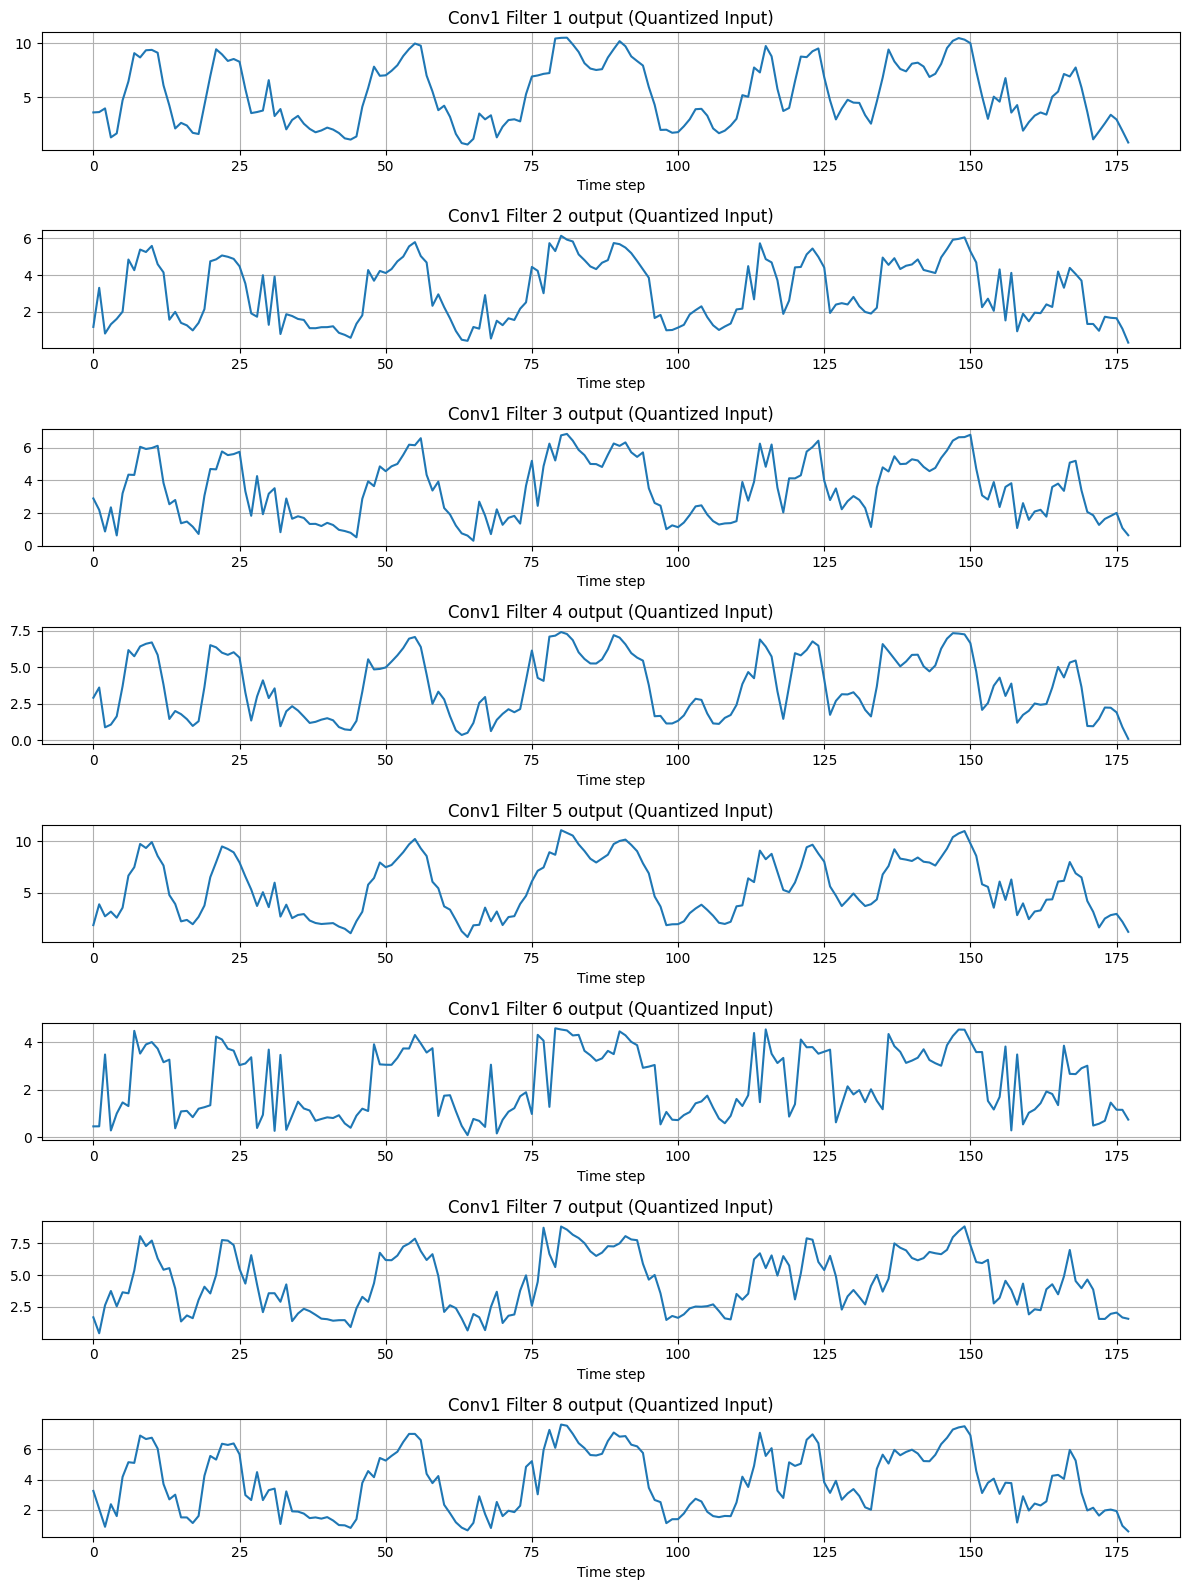

In [ ]:
# Your quantized sample (currently shape: (178, 1))
sample_idx = 0
sample = X_train[sample_idx]

print(f"Quantizing X_train[{sample_idx}]")
print("=" * 70)
print(f"Original sample shape: {sample.shape}")
print(f"Original range: [{np.min(sample):.4f}, {np.max(sample):.4f}]")
print(f"Original dtype: {sample.dtype}\n")

# Quantize to int8
sample_min = np.min(sample)
sample_max = np.max(sample)
sample_scale = (sample_max - sample_min) / 255.0
sample_zero_point = -np.round(sample_min / sample_scale).astype(int)

sample_int8 = np.round((sample / sample_scale) + sample_zero_point).astype(np.int8)

print(f"Quantized sample shape: {sample_int8.shape}")
print(f"Quantized range: [{np.min(sample_int8)}, {np.max(sample_int8)}]")
print(f"Scale: {sample_scale}")
print(f"Zero Point: {sample_zero_point}\n")

# ===== GET CONV1 OUTPUT =====
print("=" * 70)
print("GETTING CONV1 OUTPUT")
print("=" * 70)

# Dequantize back to float32 for model input
sample_float32 = ((sample_int8.astype(np.float32) - sample_zero_point) * sample_scale)

# Reshape to add batch dimension: (178, 1) -> (1, 178, 1)
single_sample = np.expand_dims(sample_float32, axis=0)
print(f"Input shape for model: {single_sample.shape}")  # Should be (1, 178, 1)

# Pass through layers to get conv1 output
x = single_sample
for layer in quantized_model.layers:
    x = layer(x)
    if layer.name == 'conv1':
        conv1_output = x.numpy()
        break

print(f"\nConv1 output shape: {conv1_output.shape}")  # Should be (1, 178, 8)
print(f"Conv1 output for quantized sample {sample_idx}:")
print(conv1_output[0])  # Shape: (178, 8)

# Visualize the 8 conv1 filters
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 1, figsize=(12, 16))
for i in range(8):
    axes[i].plot(conv1_output[0, :, i])
    axes[i].set_title(f'Conv1 Filter {i+1} output (Quantized Input)')
    axes[i].grid(True)
    axes[i].set_xlabel('Time step')
plt.tight_layout()
plt.show()

# Optional: Compare with original (non-quantized) sample
print("\n" + "=" * 70)
print("COMPARISON: ORIGINAL vs QUANTIZED INPUT")
print("=" * 70)

# Original sample through quantized model
original_input = np.expand_dims(X_train[sample_idx], axis=0)
x_orig = original_input
for layer in quantized_model.layers:
    x_orig = layer(x_orig)
    if layer.name == 'conv1':
        conv1_output_original = x_orig.numpy()
        break

print(f"Max difference in conv1 outputs: {np.max(np.abs(conv1_output - conv1_output_original))}")
print(f"Mean difference: {np.mean(np.abs(conv1_output - conv1_output_original))}")

In [33]:
quantized_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 178, 8)         │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 178, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 89, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 89, 12)         │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 89, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 44, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 528)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │        16,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,958 (70.15 KB)

 Trainable params: 17,958 (70.15 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
import numpy as np

def save_conv_output_to_header(conv_output, filename="conv1_golden_reference.h", 
                                 layer_name="conv1", sample_idx=0):
    """
    Save conv1 output to a C header file for testbench golden reference
    
    Parameters:
    -----------
    conv_output : numpy array of shape (1, time_steps, filters)
        The conv1 layer output
    filename : str
        Output header file name
    layer_name : str
        Name of the layer (for variable naming)
    sample_idx : int
        Sample index for documentation
    """
    
    # Remove batch dimension: (1, 178, 8) -> (178, 8)
    output_data = conv_output[0]
    time_steps, num_filters = output_data.shape
    
    with open(filename, 'w') as f:
        # Header guard
        guard_name = filename.upper().replace('.', '_').replace('-', '_')
        f.write(f"#ifndef {guard_name}\n")
        f.write(f"#define {guard_name}\n\n")
        
        # Documentation
        f.write(f"// Golden reference for {layer_name} output\n")
        f.write(f"// Generated from sample index: {sample_idx}\n")
        f.write(f"// Shape: ({time_steps}, {num_filters})\n")
        f.write(f"// Total elements: {time_steps * num_filters}\n\n")
        
        # Define constants
        f.write(f"#define {layer_name.upper()}_OUTPUT_TIME_STEPS {time_steps}\n")
        f.write(f"#define {layer_name.upper()}_OUTPUT_NUM_FILTERS {num_filters}\n")
        f.write(f"#define {layer_name.upper()}_OUTPUT_TOTAL_SIZE {time_steps * num_filters}\n\n")
        
        # Write as 1D array (flattened in row-major order)
        f.write(f"// Flattened array: [time_step][filter]\n")
        f.write(f"const float {layer_name}_golden_output_flat[{time_steps * num_filters}] = {{\n")
        
        flat_data = output_data.flatten()
        for i in range(0, len(flat_data), 8):  # 8 values per line
            values = flat_data[i:i+8]
            value_str = ", ".join([f"{v:.6f}f" for v in values])
            f.write(f"    {value_str}")
            if i + 8 < len(flat_data):
                f.write(",\n")
            else:
                f.write("\n")
        f.write("};\n\n")
        
        # Write as 2D array for easier indexing: [time_step][filter]
        f.write(f"// 2D array format: [time_step][filter]\n")
        f.write(f"const float {layer_name}_golden_output[{time_steps}][{num_filters}] = {{\n")
        
        for t in range(time_steps):
            f.write("    {")
            values = [f"{output_data[t, filt]:.6f}f" for filt in range(num_filters)]
            f.write(", ".join(values))
            f.write("}")
            if t < time_steps - 1:
                f.write(",\n")
            else:
                f.write("\n")
        f.write("};\n\n")
        
        # Add statistics for verification
        f.write("// Statistics for verification\n")
        f.write(f"#define {layer_name.upper()}_OUTPUT_MIN {np.min(output_data):.6f}f\n")
        f.write(f"#define {layer_name.upper()}_OUTPUT_MAX {np.max(output_data):.6f}f\n")
        f.write(f"#define {layer_name.upper()}_OUTPUT_MEAN {np.mean(output_data):.6f}f\n")
        f.write(f"#define {layer_name.upper()}_OUTPUT_STD {np.std(output_data):.6f}f\n\n")
        
        # Helper macro for accessing 2D array
        f.write("// Helper macro to access output[time_step][filter]\n")
        f.write(f"#define GET_{layer_name.upper()}_OUTPUT(t, f) {layer_name}_golden_output[t][f]\n\n")
        
        # Close header guard
        f.write(f"#endif // {guard_name}\n")
    
    print(f"✓ Saved {layer_name} output to {filename}")
    print(f"  - Shape: ({time_steps}, {num_filters})")
    print(f"  - Total elements: {time_steps * num_filters}")
    print(f"  - Range: [{np.min(output_data):.4f}, {np.max(output_data):.4f}]")


# ===== USAGE WITH YOUR QUANTIZED MODEL =====

# Get conv1 output (from your previous code)
sample_idx = 0
sample = X_train[sample_idx]

# Quantize to int8
sample_min = np.min(sample)
sample_max = np.max(sample)
sample_scale = (sample_max - sample_min) / 255.0
sample_zero_point = -np.round(sample_min / sample_scale).astype(int)
sample_int8 = np.round((sample / sample_scale) + sample_zero_point).astype(np.int8)

# Dequantize back to float32 for model input
sample_float32 = ((sample_int8.astype(np.float32) - sample_zero_point) * sample_scale)

# Reshape to add batch dimension
single_sample = np.expand_dims(sample_float32, axis=0)

# Get conv1 output
x = single_sample
for layer in quantized_model.layers:
    x = layer(x)
    if layer.name == 'conv1':
        conv1_output = x.numpy()
        break

# Save to header file
save_conv_output_to_header(
    conv1_output, 
    filename="conv1_golden_reference.h",
    layer_name="conv1",
    sample_idx=sample_idx
)

# Optional: Save other layers too
print("\n" + "=" * 70)
print("Saving other layer outputs...")
print("=" * 70)

# # Get all layer outputs
# layer_outputs = {}
# x = single_sample
# for layer in quantized_model.layers:
#     x = layer(x)
#     if layer.name in ['conv1', 'relu1', 'pool1', 'conv2', 'relu2', 'pool2']:
#         layer_outputs[layer.name] = x.numpy()
#         save_conv_output_to_header(
#             x.numpy(),
#             filename=f"{layer.name}_golden_reference.h",
#             layer_name=layer.name,
#             sample_idx=sample_idx
#         )

✓ Saved conv1 output to conv1_golden_reference.h
  - Shape: (178, 8)
  - Total elements: 1424
  - Range: [0.0953, 11.0645]

Saving other layer outputs...


In [35]:
def save_input_sample_to_header(sample, filename="input_sample.h", sample_idx=0,
                                quantized=True, scale=None, zero_point=None):
    """
    Save input sample to a C header file for testbench
    
    Parameters:
    -----------
    sample : numpy array of shape (time_steps, 1) or (time_steps,)
        The input sample
    filename : str
        Output header file name
    sample_idx : int
        Sample index for documentation
    quantized : bool
        Whether this is quantized (int8) or float32 data
    scale : float
        Quantization scale (if quantized=True)
    zero_point : int
        Quantization zero point (if quantized=True)
    """
    
    # Flatten if 2D
    if len(sample.shape) == 2:
        sample_data = sample.flatten()
    else:
        sample_data = sample
    
    time_steps = len(sample_data)
    dtype_str = "int8_t" if quantized else "float"
    
    with open(filename, 'w') as f:
        # Header guard
        guard_name = filename.upper().replace('.', '_').replace('-', '_')
        f.write(f"#ifndef {guard_name}\n")
        f.write(f"#define {guard_name}\n\n")
        
        # Include stdint for int8_t
        if quantized:
            f.write("#include <stdint.h>\n\n")
        
        # Documentation
        f.write(f"// Input sample for testbench\n")
        f.write(f"// Sample index: {sample_idx}\n")
        f.write(f"// Shape: ({time_steps}, 1)\n")
        f.write(f"// Data type: {dtype_str}\n")
        if quantized:
            f.write(f"// Quantization scale: {scale}\n")
            f.write(f"// Quantization zero point: {zero_point}\n")
        f.write(f"// Range: [{np.min(sample_data):.6f}, {np.max(sample_data):.6f}]\n\n")
        
        # Define constants
        f.write(f"#define INPUT_SAMPLE_LENGTH {time_steps}\n")
        if quantized:
            f.write(f"#define INPUT_SAMPLE_SCALE {scale:.10f}f\n")
            f.write(f"#define INPUT_SAMPLE_ZERO_POINT {zero_point}\n")
        f.write("\n")
        
        # Write the array
        f.write(f"const {dtype_str} input_sample[{time_steps}] = {{\n")
        
        for i in range(0, time_steps, 8):  # 8 values per line
            values = sample_data[i:i+8]
            if quantized:
                value_str = ", ".join([f"{int(v)}" for v in values])
            else:
                value_str = ", ".join([f"{v:.6f}f" for v in values])
            f.write(f"    {value_str}")
            if i + 8 < time_steps:
                f.write(",\n")
            else:
                f.write("\n")
        f.write("};\n\n")
        
        # Add statistics
        f.write("// Statistics\n")
        f.write(f"#define INPUT_SAMPLE_MIN {np.min(sample_data):.6f}f\n")
        f.write(f"#define INPUT_SAMPLE_MAX {np.max(sample_data):.6f}f\n")
        f.write(f"#define INPUT_SAMPLE_MEAN {np.mean(sample_data):.6f}f\n")
        f.write(f"#define INPUT_SAMPLE_STD {np.std(sample_data):.6f}f\n\n")
        
        # Dequantization macro if quantized
        if quantized:
            f.write("// Macro to dequantize to float\n")
            f.write("#define DEQUANTIZE_INPUT(idx) \\\n")
            f.write("    (((float)input_sample[idx] - INPUT_SAMPLE_ZERO_POINT) * INPUT_SAMPLE_SCALE)\n\n")
        
        # Close header guard
        f.write(f"#endif // {guard_name}\n")
    
    print(f"✓ Saved input sample to {filename}")
    print(f"  - Length: {time_steps}")
    print(f"  - Type: {dtype_str}")
    print(f"  - Range: [{np.min(sample_data):.4f}, {np.max(sample_data):.4f}]")
    if quantized:
        print(f"  - Scale: {scale:.6f}, Zero point: {zero_point}")

In [36]:
save_input_sample_to_header(
    sample_int8,
    filename="input_sample_int8.h",
    sample_idx=0,
    quantized=True,
    scale=sample_scale,
    zero_point=sample_zero_point
)

✓ Saved input sample to input_sample_int8.h
  - Length: 178
  - Type: int8_t
  - Range: [-128.0000, 127.0000]
  - Scale: 0.017855, Zero point: 120


In [37]:
import numpy as np
import os

def generate_conv_weights_header_float(model, output_dir='conv_headers', output_filename='conv_weights.h'):
    """
    Generate C header file with Conv1D weights and biases (float32)
    No quantization - stores original float values
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("=" * 80)
    print("GENERATING CONV WEIGHTS HEADER FILE (FLOAT32)")
    print("=" * 80 + "\n")
    
    header_path = os.path.join(output_dir, output_filename)
    
    with open(header_path, 'w') as f:
        # Header guard
        f.write("#ifndef CONV_WEIGHTS_H\n")
        f.write("#define CONV_WEIGHTS_H\n\n")
        
        f.write("#include <stdint.h>\n")
        f.write("#include <stddef.h>\n\n")
        
        # File description
        f.write("// ============================================\n")
        f.write("// Conv1D Layer Weights and Biases\n")
        f.write("// Data Type: float32 (no quantization)\n")
        f.write("// Auto-generated for Vivado HLS IP\n")
        f.write("// ============================================\n\n")
        
        # Get actual weights and biases from model
        conv1_weights, conv1_bias = model.get_layer("conv1").get_weights()
        conv2_weights, conv2_bias = model.get_layer("conv2").get_weights()
        
        # ===== CONV1 LAYER =====
        print("Processing Conv1 Layer...")
        print(f"  Weights shape: {conv1_weights.shape}")
        print(f"  Bias shape: {conv1_bias.shape}")
        print(f"  Weights range: [{np.min(conv1_weights):.6f}, {np.max(conv1_weights):.6f}]")
        print(f"  Bias range: [{np.min(conv1_bias):.6f}, {np.max(conv1_bias):.6f}]\n")
        
        kernel_size_1, in_channels_1, out_filters_1 = conv1_weights.shape
        
        f.write("// ============================================\n")
        f.write("// CONV1 LAYER\n")
        f.write("// ============================================\n")
        f.write(f"// Kernel Size: {kernel_size_1}\n")
        f.write(f"// Input Channels: {in_channels_1}\n")
        f.write(f"// Output Filters: {out_filters_1}\n")
        f.write(f"// Total Weights: {conv1_weights.size}\n")
        f.write(f"// Total Biases: {len(conv1_bias)}\n")
        f.write(f"// Data Type: float32\n\n")
        
        # Dimension macros
        f.write(f"#define CONV1_KERNEL_SIZE {kernel_size_1}\n")
        f.write(f"#define CONV1_IN_CHANNELS {in_channels_1}\n")
        f.write(f"#define CONV1_OUT_FILTERS {out_filters_1}\n")
        f.write(f"#define CONV1_WEIGHT_SIZE {conv1_weights.size}\n")
        f.write(f"#define CONV1_BIAS_SIZE {len(conv1_bias)}\n\n")
        
        # Weights array (flattened)
        f.write(f"// Conv1 Weights (float32): shape ({kernel_size_1}, {in_channels_1}, {out_filters_1})\n")
        f.write(f"// Layout: [kernel_idx][channel_idx][filter_idx]\n")
        f.write(f"const float conv1_weights[CONV1_WEIGHT_SIZE] = {{\n")
        
        weights_flat_1 = conv1_weights.flatten()
        for idx, w in enumerate(weights_flat_1):
            f.write(f"    {float(w):.10f}f")
            if idx < len(weights_flat_1) - 1:
                f.write(",")
            if (idx + 1) % 8 == 0:
                f.write("\n")
            elif idx < len(weights_flat_1) - 1:
                f.write(" ")
        f.write("\n};\n\n")
        
        # Bias array
        f.write(f"// Conv1 Biases (float32): {out_filters_1} biases\n")
        f.write(f"const float conv1_bias[CONV1_BIAS_SIZE] = {{\n")
        for idx, b in enumerate(conv1_bias):
            f.write(f"    {float(b):.10f}f")
            if idx < len(conv1_bias) - 1:
                f.write(",")
            f.write("\n")
        f.write("};\n\n")
        
        # ===== CONV2 LAYER =====
        print("Processing Conv2 Layer...")
        print(f"  Weights shape: {conv2_weights.shape}")
        print(f"  Bias shape: {conv2_bias.shape}")
        print(f"  Weights range: [{np.min(conv2_weights):.6f}, {np.max(conv2_weights):.6f}]")
        print(f"  Bias range: [{np.min(conv2_bias):.6f}, {np.max(conv2_bias):.6f}]\n")
        
        kernel_size_2, in_channels_2, out_filters_2 = conv2_weights.shape
        
        f.write("// ============================================\n")
        f.write("// CONV2 LAYER\n")
        f.write("// ============================================\n")
        f.write(f"// Kernel Size: {kernel_size_2}\n")
        f.write(f"// Input Channels: {in_channels_2}\n")
        f.write(f"// Output Filters: {out_filters_2}\n")
        f.write(f"// Total Weights: {conv2_weights.size}\n")
        f.write(f"// Total Biases: {len(conv2_bias)}\n")
        f.write(f"// Data Type: float32\n\n")
        
        # Dimension macros
        f.write(f"#define CONV2_KERNEL_SIZE {kernel_size_2}\n")
        f.write(f"#define CONV2_IN_CHANNELS {in_channels_2}\n")
        f.write(f"#define CONV2_OUT_FILTERS {out_filters_2}\n")
        f.write(f"#define CONV2_WEIGHT_SIZE {conv2_weights.size}\n")
        f.write(f"#define CONV2_BIAS_SIZE {len(conv2_bias)}\n\n")
        
        # Weights array
        f.write(f"// Conv2 Weights (float32): shape ({kernel_size_2}, {in_channels_2}, {out_filters_2})\n")
        f.write(f"// Layout: [kernel_idx][channel_idx][filter_idx]\n")
        f.write(f"const float conv2_weights[CONV2_WEIGHT_SIZE] = {{\n")
        
        weights_flat_2 = conv2_weights.flatten()
        for idx, w in enumerate(weights_flat_2):
            f.write(f"    {float(w):.10f}f")
            if idx < len(weights_flat_2) - 1:
                f.write(",")
            if (idx + 1) % 8 == 0:
                f.write("\n")
            elif idx < len(weights_flat_2) - 1:
                f.write(" ")
        f.write("\n};\n\n")
        
        # Bias array
        f.write(f"// Conv2 Biases (float32): {out_filters_2} biases\n")
        f.write(f"const float conv2_bias[CONV2_BIAS_SIZE] = {{\n")
        for idx, b in enumerate(conv2_bias):
            f.write(f"    {float(b):.10f}f")
            if idx < len(conv2_bias) - 1:
                f.write(",")
            f.write("\n")
        f.write("};\n\n")
        
        # ===== STRUCT DEFINITIONS =====
        f.write("// ============================================\n")
        f.write("// Struct for Conv Layer Parameters\n")
        f.write("// ============================================\n")
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int kernel_size;\n")
        f.write("    int in_channels;\n")
        f.write("    int out_filters;\n")
        f.write("} ConvLayer_t;\n\n")
        
        # ===== CONV LAYERS ARRAY =====
        f.write("// ============================================\n")
        f.write("// Conv Layers Array\n")
        f.write("// ============================================\n")
        f.write("#define NUM_CONV_LAYERS 2\n\n")
        
        f.write("static const ConvLayer_t conv_layers[NUM_CONV_LAYERS] = {\n")
        f.write("    // Conv1 Layer\n")
        f.write("    {\n")
        f.write("        .weights = conv1_weights,\n")
        f.write("        .bias = conv1_bias,\n")
        f.write("        .kernel_size = CONV1_KERNEL_SIZE,\n")
        f.write("        .in_channels = CONV1_IN_CHANNELS,\n")
        f.write("        .out_filters = CONV1_OUT_FILTERS\n")
        f.write("    },\n")
        
        f.write("    // Conv2 Layer\n")
        f.write("    {\n")
        f.write("        .weights = conv2_weights,\n")
        f.write("        .bias = conv2_bias,\n")
        f.write("        .kernel_size = CONV2_KERNEL_SIZE,\n")
        f.write("        .in_channels = CONV2_IN_CHANNELS,\n")
        f.write("        .out_filters = CONV2_OUT_FILTERS\n")
        f.write("    }\n")
        f.write("};\n\n")
        
        # ===== HELPER MACROS =====
        f.write("// ============================================\n")
        f.write("// Helper Macros\n")
        f.write("// ============================================\n\n")
        
        f.write("// Get weight at position [k, c, f] for a layer\n")
        f.write("// layer: 0 for conv1, 1 for conv2\n")
        f.write("// k: kernel position, c: input channel, f: output filter\n")
        f.write("#define GET_WEIGHT(layer, k, c, f) \\\n")
        f.write("    conv_layers[layer].weights[(k) * conv_layers[layer].in_channels * conv_layers[layer].out_filters + \\\n")
        f.write("                                (c) * conv_layers[layer].out_filters + (f)]\n\n")
        
        f.write("// Get bias at position [f] for a layer\n")
        f.write("#define GET_BIAS(layer, f) conv_layers[layer].bias[f]\n\n")
        
        # End header guard
        f.write("#endif // CONV_WEIGHTS_H\n")
    
    print(f"✓ Header file generated: {header_path}\n")
    
    # ===== Print summary =====
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"\nFile: {header_path}\n")
    
    print("Conv1 Layer:")
    print(f"  Weights: {kernel_size_1}x{in_channels_1}x{out_filters_1} (float32)")
    print(f"  Biases: {out_filters_1} (float32)")
    print(f"  Total size: {conv1_weights.nbytes + conv1_bias.nbytes} bytes\n")
    
    print("Conv2 Layer:")
    print(f"  Weights: {kernel_size_2}x{in_channels_2}x{out_filters_2} (float32)")
    print(f"  Biases: {out_filters_2} (float32)")
    print(f"  Total size: {conv2_weights.nbytes + conv2_bias.nbytes} bytes\n")
    
    total_size = conv1_weights.nbytes + conv1_bias.nbytes + conv2_weights.nbytes + conv2_bias.nbytes
    print(f"Total memory: {total_size / 1024:.2f} KB\n")
    
    print("Includes:")
    print(f"  • Dimension macros (CONV1_KERNEL_SIZE, etc.)")
    print(f"  • Weight and bias arrays (float32)")
    print(f"  • ConvLayer_t struct")
    print(f"  • Helper macros (GET_WEIGHT, GET_BIAS)")
    
    return header_path


# ===== USAGE =====
# Generate header file with model weights (no quantization)
header_file = generate_conv_weights_header_float(model)

GENERATING CONV WEIGHTS HEADER FILE (FLOAT32)

Processing Conv1 Layer...
  Weights shape: (5, 1, 8)
  Bias shape: (8,)
  Weights range: [-0.399255, 0.470675]
  Bias range: [-0.147508, 0.125017]

Processing Conv2 Layer...
  Weights shape: (3, 8, 12)
  Bias shape: (12,)
  Weights range: [-0.437165, 0.473465]
  Bias range: [-0.222975, 0.071166]

✓ Header file generated: conv_headers/conv_weights.h

SUMMARY

File: conv_headers/conv_weights.h

Conv1 Layer:
  Weights: 5x1x8 (float32)
  Biases: 8 (float32)
  Total size: 192 bytes

Conv2 Layer:
  Weights: 3x8x12 (float32)
  Biases: 12 (float32)
  Total size: 1200 bytes

Total memory: 1.36 KB

Includes:
  • Dimension macros (CONV1_KERNEL_SIZE, etc.)
  • Weight and bias arrays (float32)
  • ConvLayer_t struct
  • Helper macros (GET_WEIGHT, GET_BIAS)


In [38]:
import numpy as np
import os

def generate_all_layers_header(model, output_dir='conv_headers', output_filename='all_weights.h'):
    """
    Generate C header file with ALL layer weights and biases (float32)
    Includes: Conv1D, Conv2D, Dense, and Activation layers
    No quantization - stores original float values
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("=" * 80)
    print("GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)")
    print("=" * 80 + "\n")
    
    header_path = os.path.join(output_dir, output_filename)
    
    # Get all layers with weights
    layers_with_weights = []
    for layer in model.layers:
        if hasattr(layer, 'get_weights') and len(layer.get_weights()) > 0:
            weights, bias = layer.get_weights()
            layers_with_weights.append({
                'name': layer.name,
                'type': layer.__class__.__name__,
                'weights': weights,
                'bias': bias
            })
    
    print(f"Found {len(layers_with_weights)} layers with weights:\n")
    for i, layer_info in enumerate(layers_with_weights):
        print(f"{i+1}. {layer_info['name']} ({layer_info['type']})")
        print(f"   Weights: {layer_info['weights'].shape}")
        print(f"   Bias: {layer_info['bias'].shape}\n")
    
    with open(header_path, 'w') as f:
        # Header guard
        f.write("#ifndef ALL_WEIGHTS_H\n")
        f.write("#define ALL_WEIGHTS_H\n\n")
        
        f.write("#include <stdint.h>\n")
        f.write("#include <stddef.h>\n\n")
        
        # File description
        f.write("// ============================================\n")
        f.write("// All Layer Weights and Biases\n")
        f.write("// Data Type: float32 (no quantization)\n")
        f.write("// Auto-generated for Vivado HLS IP\n")
        f.write("// ============================================\n\n")
        
        total_weights = 0
        total_memory = 0
        
        # Process each layer
        for layer_idx, layer_info in enumerate(layers_with_weights):
            layer_name = layer_info['name']
            layer_type = layer_info['type']
            weights = layer_info['weights']
            bias = layer_info['bias']
            
            print(f"Processing {layer_name} ({layer_type})...")
            
            # ===== LAYER HEADER =====
            f.write("// " + "=" * 76 + "\n")
            f.write(f"// {layer_name.upper()} LAYER ({layer_type})\n")
            f.write("// " + "=" * 76 + "\n")
            
            f.write(f"// Weights shape: {weights.shape}\n")
            f.write(f"// Bias shape: {bias.shape}\n")
            f.write(f"// Weights range: [{np.min(weights):.6f}, {np.max(weights):.6f}]\n")
            f.write(f"// Bias range: [{np.min(bias):.6f}, {np.max(bias):.6f}]\n")
            f.write(f"// Data Type: float32\n\n")
            
            # Get dimensions
            if layer_type == 'Conv1D':
                kernel_size, in_channels, out_filters = weights.shape
                f.write(f"// Kernel Size: {kernel_size}\n")
                f.write(f"// Input Channels: {in_channels}\n")
                f.write(f"// Output Filters: {out_filters}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_KERNEL_SIZE {kernel_size}\n")
                f.write(f"#define {layer_name.upper()}_IN_CHANNELS {in_channels}\n")
                f.write(f"#define {layer_name.upper()}_OUT_FILTERS {out_filters}\n")
                
            elif layer_type == 'Dense':
                input_size, output_size = weights.shape
                f.write(f"// Input Size: {input_size}\n")
                f.write(f"// Output Size: {output_size}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_INPUT_SIZE {input_size}\n")
                f.write(f"#define {layer_name.upper()}_OUTPUT_SIZE {output_size}\n")
            
            f.write(f"#define {layer_name.upper()}_WEIGHT_SIZE {weights.size}\n")
            f.write(f"#define {layer_name.upper()}_BIAS_SIZE {len(bias)}\n\n")
            
            # Total weights and memory
            layer_memory = weights.nbytes + bias.nbytes
            total_weights += weights.size
            total_memory += layer_memory
            
            # ===== WEIGHTS ARRAY =====
            f.write(f"// {layer_name.upper()} Weights (float32)\n")
            f.write(f"const float {layer_name}_weights[{layer_name.upper()}_WEIGHT_SIZE] = {{\n")
            
            weights_flat = weights.flatten()
            for idx, w in enumerate(weights_flat):
                f.write(f"    {float(w):.10f}f")
                if idx < len(weights_flat) - 1:
                    f.write(",")
                if (idx + 1) % 8 == 0:
                    f.write("\n")
                elif idx < len(weights_flat) - 1:
                    f.write(" ")
            f.write("\n};\n\n")
            
            # ===== BIAS ARRAY =====
            f.write(f"// {layer_name.upper()} Biases (float32)\n")
            f.write(f"const float {layer_name}_bias[{layer_name.upper()}_BIAS_SIZE] = {{\n")
            for idx, b in enumerate(bias):
                f.write(f"    {float(b):.10f}f")
                if idx < len(bias) - 1:
                    f.write(",")
                f.write("\n")
            f.write("};\n\n")
        
        # ===== STRUCT DEFINITIONS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Layer Structure Definitions\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        # Conv1D struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int kernel_size;\n")
        f.write("    int in_channels;\n")
        f.write("    int out_filters;\n")
        f.write("} Conv1DLayer_t;\n\n")
        
        # Dense struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int input_size;\n")
        f.write("    int output_size;\n")
        f.write("} DenseLayer_t;\n\n")
        
        # ===== CONV LAYERS ARRAY =====
        conv_layers = [l for l in layers_with_weights if l['type'] == 'Conv1D']
        if conv_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Conv1D Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_CONV_LAYERS {len(conv_layers)}\n\n")
            
            f.write("static const Conv1DLayer_t conv_layers[NUM_CONV_LAYERS] = {\n")
            for idx, layer_info in enumerate(conv_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                kernel_size, in_channels, out_filters = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .kernel_size = {name.upper()}_KERNEL_SIZE,\n")
                f.write(f"        .in_channels = {name.upper()}_IN_CHANNELS,\n")
                f.write(f"        .out_filters = {name.upper()}_OUT_FILTERS\n")
                f.write(f"    }}")
                
                if idx < len(conv_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== DENSE LAYERS ARRAY =====
        dense_layers = [l for l in layers_with_weights if l['type'] == 'Dense']
        if dense_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Dense Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_DENSE_LAYERS {len(dense_layers)}\n\n")
            
            f.write("static const DenseLayer_t dense_layers[NUM_DENSE_LAYERS] = {\n")
            for idx, layer_info in enumerate(dense_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                input_size, output_size = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .input_size = {name.upper()}_INPUT_SIZE,\n")
                f.write(f"        .output_size = {name.upper()}_OUTPUT_SIZE\n")
                f.write(f"    }}")
                
                if idx < len(dense_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== HELPER MACROS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Helper Macros\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        f.write("// Get weight at position [k, c, f] for Conv1D layer\n")
        f.write("// layer_idx: index in conv_layers array\n")
        f.write("#define GET_CONV_WEIGHT(layer_idx, k, c, f) \\\n")
        f.write("    conv_layers[layer_idx].weights[(k) * conv_layers[layer_idx].in_channels * conv_layers[layer_idx].out_filters + \\\n")
        f.write("                                   (c) * conv_layers[layer_idx].out_filters + (f)]\n\n")
        
        f.write("// Get bias for Conv1D layer\n")
        f.write("#define GET_CONV_BIAS(layer_idx, f) conv_layers[layer_idx].bias[f]\n\n")
        
        f.write("// Get weight at position [i, j] for Dense layer\n")
        f.write("// layer_idx: index in dense_layers array\n")
        f.write("#define GET_DENSE_WEIGHT(layer_idx, i, j) \\\n")
        f.write("    dense_layers[layer_idx].weights[(i) * dense_layers[layer_idx].output_size + (j)]\n\n")
        
        f.write("// Get bias for Dense layer\n")
        f.write("#define GET_DENSE_BIAS(layer_idx, j) dense_layers[layer_idx].bias[j]\n\n")
        
        # End header guard
        f.write("#endif // ALL_WEIGHTS_H\n")
    
    print(f"\n✓ Header file generated: {header_path}\n")
    
    # ===== Print summary =====
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"\nFile: {header_path}\n")
    
    print("Layers Summary:")
    for i, layer_info in enumerate(layers_with_weights, 1):
        name = layer_info['name']
        layer_type = layer_info['type']
        weights = layer_info['weights']
        bias = layer_info['bias']
        layer_memory = weights.nbytes + bias.nbytes
        
        print(f"{i}. {name} ({layer_type})")
        print(f"   Weights: {weights.shape} = {weights.size} values")
        print(f"   Bias: {bias.shape} = {len(bias)} values")
        print(f"   Memory: {layer_memory / 1024:.2f} KB\n")
    
    print(f"Total Values: {total_weights:,}")
    print(f"Total Memory: {total_memory / 1024:.2f} KB ({total_memory / (1024*1024):.2f} MB)")
    
    print("\nIncludes:")
    print(f"  • All layer weights and biases (float32)")
    print(f"  • Dimension macros for each layer")
    print(f"  • Conv1DLayer_t and DenseLayer_t structs")
    print(f"  • Layer arrays (conv_layers[], dense_layers[])")
    print(f"  • Helper macros (GET_CONV_WEIGHT, GET_DENSE_WEIGHT, etc.)")
    
    return header_path


# ===== USAGE =====
# Generate header file with ALL layers (no quantization)
header_file = generate_all_layers_header(model)

GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)

Found 6 layers with weights:

1. conv1 (Conv1D)
   Weights: (5, 1, 8)
   Bias: (8,)

2. conv2 (Conv1D)
   Weights: (3, 8, 12)
   Bias: (12,)

3. fc1 (Dense)
   Weights: (528, 32)
   Bias: (32,)

4. fc2 (Dense)
   Weights: (32, 16)
   Bias: (16,)

5. fc3 (Dense)
   Weights: (16, 8)
   Bias: (8,)

6. softmax (Dense)
   Weights: (8, 2)
   Bias: (2,)

Processing conv1 (Conv1D)...
Processing conv2 (Conv1D)...
Processing fc1 (Dense)...
Processing fc2 (Dense)...
Processing fc3 (Dense)...
Processing softmax (Dense)...

✓ Header file generated: conv_headers/all_weights.h

SUMMARY

File: conv_headers/all_weights.h

Layers Summary:
1. conv1 (Conv1D)
   Weights: (5, 1, 8) = 40 values
   Bias: (8,) = 8 values
   Memory: 0.19 KB

2. conv2 (Conv1D)
   Weights: (3, 8, 12) = 288 values
   Bias: (12,) = 12 values
   Memory: 1.17 KB

3. fc1 (Dense)
   Weights: (528, 32) = 16896 values
   Bias: (32,) = 32 values
   Memory: 66.12 KB

4. fc2 (Dense)
   We

In [39]:
import numpy as np
import os

def generate_all_layers_header(model, output_dir='conv_headers', output_filename='all_weights.h'):
    """
    Generate C header file with ALL layer weights and biases (float32)
    Includes: Conv1D, Conv2D, Dense, and Activation layers
    No quantization - stores original float values
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("=" * 80)
    print("GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)")
    print("=" * 80 + "\n")
    
    header_path = os.path.join(output_dir, output_filename)
    
    # Get all layers with weights
    layers_with_weights = []
    for layer in model.layers:
        if hasattr(layer, 'get_weights') and len(layer.get_weights()) > 0:
            weights, bias = layer.get_weights()
            layers_with_weights.append({
                'name': layer.name,
                'type': layer.__class__.__name__,
                'weights': weights,
                'bias': bias
            })
    
    print(f"Found {len(layers_with_weights)} layers with weights:\n")
    for i, layer_info in enumerate(layers_with_weights):
        print(f"{i+1}. {layer_info['name']} ({layer_info['type']})")
        print(f"   Weights: {layer_info['weights'].shape}")
        print(f"   Bias: {layer_info['bias'].shape}\n")
    
    with open(header_path, 'w') as f:
        # Header guard
        f.write("#ifndef ALL_WEIGHTS_H\n")
        f.write("#define ALL_WEIGHTS_H\n\n")
        
        f.write("#include <stdint.h>\n")
        f.write("#include <stddef.h>\n\n")
        
        # File description
        f.write("// ============================================\n")
        f.write("// All Layer Weights and Biases\n")
        f.write("// Data Type: float32 (no quantization)\n")
        f.write("// Auto-generated for Vivado HLS IP\n")
        f.write("// ============================================\n\n")
        
        total_weights = 0
        total_memory = 0
        
        # Process each layer
        for layer_idx, layer_info in enumerate(layers_with_weights):
            layer_name = layer_info['name']
            layer_type = layer_info['type']
            weights = layer_info['weights']
            bias = layer_info['bias']
            
            print(f"Processing {layer_name} ({layer_type})...")
            
            # ===== LAYER HEADER =====
            f.write("// " + "=" * 76 + "\n")
            f.write(f"// {layer_name.upper()} LAYER ({layer_type})\n")
            f.write("// " + "=" * 76 + "\n")
            
            f.write(f"// Weights shape: {weights.shape}\n")
            f.write(f"// Bias shape: {bias.shape}\n")
            f.write(f"// Weights range: [{np.min(weights):.6f}, {np.max(weights):.6f}]\n")
            f.write(f"// Bias range: [{np.min(bias):.6f}, {np.max(bias):.6f}]\n")
            f.write(f"// Data Type: float32\n\n")
            
            # Get dimensions
            if layer_type == 'Conv1D':
                kernel_size, in_channels, out_filters = weights.shape
                f.write(f"// Kernel Size: {kernel_size}\n")
                f.write(f"// Input Channels: {in_channels}\n")
                f.write(f"// Output Filters: {out_filters}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_KERNEL_SIZE {kernel_size}\n")
                f.write(f"#define {layer_name.upper()}_IN_CHANNELS {in_channels}\n")
                f.write(f"#define {layer_name.upper()}_OUT_FILTERS {out_filters}\n")
                
            elif layer_type == 'Dense':
                input_size, output_size = weights.shape
                f.write(f"// Input Size: {input_size}\n")
                f.write(f"// Output Size: {output_size}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_INPUT_SIZE {input_size}\n")
                f.write(f"#define {layer_name.upper()}_OUTPUT_SIZE {output_size}\n")
            
            f.write(f"#define {layer_name.upper()}_WEIGHT_SIZE {weights.size}\n")
            f.write(f"#define {layer_name.upper()}_BIAS_SIZE {len(bias)}\n\n")
            
            # Total weights and memory
            layer_memory = weights.nbytes + bias.nbytes
            total_weights += weights.size
            total_memory += layer_memory
            
            # ===== WEIGHTS ARRAY =====
            f.write(f"// {layer_name.upper()} Weights (float32)\n")
            f.write(f"// Shape: {weights.shape}\n")
            f.write(f"// Note: Weights stored in original shape, access using layer structure\n")
            f.write(f"// To access: Use pointer and calculate offset based on shape\n")
            f.write(f"const float {layer_name}_weights[{layer_name.upper()}_WEIGHT_SIZE];\n")
            f.write(f"// Weights defined externally or in separate .c file\n\n")
            
            # ===== BIAS ARRAY =====
            f.write(f"// {layer_name.upper()} Biases (float32)\n")
            f.write(f"// Shape: {bias.shape}\n")
            f.write(f"const float {layer_name}_bias[{layer_name.upper()}_BIAS_SIZE];\n")
            f.write(f"// Biases defined externally or in separate .c file\n\n")
        
        # ===== STRUCT DEFINITIONS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Layer Structure Definitions\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        # Conv1D struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int kernel_size;\n")
        f.write("    int in_channels;\n")
        f.write("    int out_filters;\n")
        f.write("} Conv1DLayer_t;\n\n")
        
        # Dense struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int input_size;\n")
        f.write("    int output_size;\n")
        f.write("} DenseLayer_t;\n\n")
        
        # ===== CONV LAYERS ARRAY =====
        conv_layers = [l for l in layers_with_weights if l['type'] == 'Conv1D']
        if conv_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Conv1D Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_CONV_LAYERS {len(conv_layers)}\n\n")
            
            f.write("static const Conv1DLayer_t conv_layers[NUM_CONV_LAYERS] = {\n")
            for idx, layer_info in enumerate(conv_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                kernel_size, in_channels, out_filters = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .kernel_size = {name.upper()}_KERNEL_SIZE,\n")
                f.write(f"        .in_channels = {name.upper()}_IN_CHANNELS,\n")
                f.write(f"        .out_filters = {name.upper()}_OUT_FILTERS\n")
                f.write(f"    }}")
                
                if idx < len(conv_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== DENSE LAYERS ARRAY =====
        dense_layers = [l for l in layers_with_weights if l['type'] == 'Dense']
        if dense_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Dense Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_DENSE_LAYERS {len(dense_layers)}\n\n")
            
            f.write("static const DenseLayer_t dense_layers[NUM_DENSE_LAYERS] = {\n")
            for idx, layer_info in enumerate(dense_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                input_size, output_size = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .input_size = {name.upper()}_INPUT_SIZE,\n")
                f.write(f"        .output_size = {name.upper()}_OUTPUT_SIZE\n")
                f.write(f"    }}")
                
                if idx < len(dense_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== HELPER MACROS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Helper Macros\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        f.write("// Get weight at position [k, c, f] for Conv1D layer\n")
        f.write("// layer_idx: index in conv_layers array\n")
        f.write("#define GET_CONV_WEIGHT(layer_idx, k, c, f) \\\n")
        f.write("    conv_layers[layer_idx].weights[(k) * conv_layers[layer_idx].in_channels * conv_layers[layer_idx].out_filters + \\\n")
        f.write("                                   (c) * conv_layers[layer_idx].out_filters + (f)]\n\n")
        
        f.write("// Get bias for Conv1D layer\n")
        f.write("#define GET_CONV_BIAS(layer_idx, f) conv_layers[layer_idx].bias[f]\n\n")
        
        f.write("// Get weight at position [i, j] for Dense layer\n")
        f.write("// layer_idx: index in dense_layers array\n")
        f.write("#define GET_DENSE_WEIGHT(layer_idx, i, j) \\\n")
        f.write("    dense_layers[layer_idx].weights[(i) * dense_layers[layer_idx].output_size + (j)]\n\n")
        
        f.write("// Get bias for Dense layer\n")
        f.write("#define GET_DENSE_BIAS(layer_idx, j) dense_layers[layer_idx].bias[j]\n\n")
        
        # End header guard
        f.write("#endif // ALL_WEIGHTS_H\n")
    
    print(f"\n✓ Header file generated: {header_path}\n")
    
    # ===== Print summary =====
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"\nFile: {header_path}\n")
    
    print("Layers Summary:")
    for i, layer_info in enumerate(layers_with_weights, 1):
        name = layer_info['name']
        layer_type = layer_info['type']
        weights = layer_info['weights']
        bias = layer_info['bias']
        layer_memory = weights.nbytes + bias.nbytes
        
        print(f"{i}. {name} ({layer_type})")
        print(f"   Weights: {weights.shape} = {weights.size} values")
        print(f"   Bias: {bias.shape} = {len(bias)} values")
        print(f"   Memory: {layer_memory / 1024:.2f} KB\n")
    
    print(f"Total Values: {total_weights:,}")
    print(f"Total Memory: {total_memory / 1024:.2f} KB ({total_memory / (1024*1024):.2f} MB)")
    
    print("\nIncludes:")
    print(f"  • All layer weights and biases (float32)")
    print(f"  • Dimension macros for each layer")
    print(f"  • Conv1DLayer_t and DenseLayer_t structs")
    print(f"  • Layer arrays (conv_layers[], dense_layers[])")
    print(f"  • Helper macros (GET_CONV_WEIGHT, GET_DENSE_WEIGHT, etc.)")
    
    return header_path


# ===== USAGE =====
# Generate header file with ALL layers (no quantization)
header_file = generate_all_layers_header(model)

GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)

Found 6 layers with weights:

1. conv1 (Conv1D)
   Weights: (5, 1, 8)
   Bias: (8,)

2. conv2 (Conv1D)
   Weights: (3, 8, 12)
   Bias: (12,)

3. fc1 (Dense)
   Weights: (528, 32)
   Bias: (32,)

4. fc2 (Dense)
   Weights: (32, 16)
   Bias: (16,)

5. fc3 (Dense)
   Weights: (16, 8)
   Bias: (8,)

6. softmax (Dense)
   Weights: (8, 2)
   Bias: (2,)

Processing conv1 (Conv1D)...
Processing conv2 (Conv1D)...
Processing fc1 (Dense)...
Processing fc2 (Dense)...
Processing fc3 (Dense)...
Processing softmax (Dense)...

✓ Header file generated: conv_headers/all_weights.h

SUMMARY

File: conv_headers/all_weights.h

Layers Summary:
1. conv1 (Conv1D)
   Weights: (5, 1, 8) = 40 values
   Bias: (8,) = 8 values
   Memory: 0.19 KB

2. conv2 (Conv1D)
   Weights: (3, 8, 12) = 288 values
   Bias: (12,) = 12 values
   Memory: 1.17 KB

3. fc1 (Dense)
   Weights: (528, 32) = 16896 values
   Bias: (32,) = 32 values
   Memory: 66.12 KB

4. fc2 (Dense)
   We

In [40]:
import numpy as np
import os

def generate_all_layers_header(model, output_dir='conv_headers', output_filename='all_weights.h'):
    """
    Generate C header file with ALL layer weights and biases (float32)
    Includes: Conv1D, Conv2D, Dense, and Activation layers
    No quantization - stores original float values
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("=" * 80)
    print("GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)")
    print("=" * 80 + "\n")
    
    header_path = os.path.join(output_dir, output_filename)
    
    # Get all layers with weights
    layers_with_weights = []
    for layer in model.layers:
        if hasattr(layer, 'get_weights') and len(layer.get_weights()) > 0:
            weights, bias = layer.get_weights()
            layers_with_weights.append({
                'name': layer.name,
                'type': layer.__class__.__name__,
                'weights': weights,
                'bias': bias
            })
    
    print(f"Found {len(layers_with_weights)} layers with weights:\n")
    for i, layer_info in enumerate(layers_with_weights):
        print(f"{i+1}. {layer_info['name']} ({layer_info['type']})")
        print(f"   Weights: {layer_info['weights'].shape}")
        print(f"   Bias: {layer_info['bias'].shape}\n")
    
    with open(header_path, 'w') as f:
        # Header guard
        f.write("#ifndef ALL_WEIGHTS_H\n")
        f.write("#define ALL_WEIGHTS_H\n\n")
        
        f.write("#include <stdint.h>\n")
        f.write("#include <stddef.h>\n\n")
        
        # File description
        f.write("// ============================================\n")
        f.write("// All Layer Weights and Biases\n")
        f.write("// Data Type: float32 (no quantization)\n")
        f.write("// Auto-generated for Vivado HLS IP\n")
        f.write("// ============================================\n\n")
        
        total_weights = 0
        total_memory = 0
        
        # Process each layer
        for layer_idx, layer_info in enumerate(layers_with_weights):
            layer_name = layer_info['name']
            layer_type = layer_info['type']
            weights = layer_info['weights']
            bias = layer_info['bias']
            
            print(f"Processing {layer_name} ({layer_type})...")
            
            # ===== LAYER HEADER =====
            f.write("// " + "=" * 76 + "\n")
            f.write(f"// {layer_name.upper()} LAYER ({layer_type})\n")
            f.write("// " + "=" * 76 + "\n")
            
            f.write(f"// Weights shape: {weights.shape}\n")
            f.write(f"// Bias shape: {bias.shape}\n")
            f.write(f"// Weights range: [{np.min(weights):.6f}, {np.max(weights):.6f}]\n")
            f.write(f"// Bias range: [{np.min(bias):.6f}, {np.max(bias):.6f}]\n")
            f.write(f"// Data Type: float32\n\n")
            
            # Get dimensions
            if layer_type == 'Conv1D':
                kernel_size, in_channels, out_filters = weights.shape
                f.write(f"// Kernel Size: {kernel_size}\n")
                f.write(f"// Input Channels: {in_channels}\n")
                f.write(f"// Output Filters: {out_filters}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_KERNEL_SIZE {kernel_size}\n")
                f.write(f"#define {layer_name.upper()}_IN_CHANNELS {in_channels}\n")
                f.write(f"#define {layer_name.upper()}_OUT_FILTERS {out_filters}\n")
                
            elif layer_type == 'Dense':
                input_size, output_size = weights.shape
                f.write(f"// Input Size: {input_size}\n")
                f.write(f"// Output Size: {output_size}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_INPUT_SIZE {input_size}\n")
                f.write(f"#define {layer_name.upper()}_OUTPUT_SIZE {output_size}\n")
            
            f.write(f"#define {layer_name.upper()}_WEIGHT_SIZE {weights.size}\n")
            f.write(f"#define {layer_name.upper()}_BIAS_SIZE {len(bias)}\n\n")
            
            # Total weights and memory
            layer_memory = weights.nbytes + bias.nbytes
            total_weights += weights.size
            total_memory += layer_memory
            
            # ===== WEIGHTS ARRAY =====
            f.write(f"// {layer_name.upper()} Weights (float32)\n")
            f.write(f"// Original Shape: {weights.shape}\n")
            f.write(f"// Stored as 1D array for C compatibility\n")
            f.write(f"const float {layer_name}_weights[{layer_name.upper()}_WEIGHT_SIZE] = {{\n")
            
            weights_flat = weights.flatten()
            # Write in organized way with comments for better readability
            if layer_type == 'Conv1D':
                kernel_size, in_channels, out_filters = weights.shape
                idx = 0
                for k in range(kernel_size):
                    for c in range(in_channels):
                        for filt in range(out_filters):
                            f.write(f"    {float(weights_flat[idx]):.10f}f")
                            idx += 1
                            if idx < len(weights_flat):
                                f.write(",")
                            if idx % 8 == 0:
                                f.write(f"  // k={k}, c={c}, f={filt}\n")
                            elif idx < len(weights_flat):
                                f.write(" ")
            else:  # Dense
                rows, cols = weights.shape
                for i in range(rows):
                    for j in range(cols):
                        val = weights_flat[i * cols + j]
                        f.write(f"    {float(val):.10f}f")
                        if i * cols + j < len(weights_flat) - 1:
                            f.write(",")
                        if (j + 1) % 8 == 0 or j == cols - 1:
                            f.write(f"  // row={i}\n")
                        elif i * cols + j < len(weights_flat) - 1:
                            f.write(" ")
            
            f.write("};\n\n")
            
            # ===== BIAS ARRAY =====
            f.write(f"// {layer_name.upper()} Biases (float32)\n")
            f.write(f"// Shape: {bias.shape}\n")
            f.write(f"const float {layer_name}_bias[{layer_name.upper()}_BIAS_SIZE] = {{\n")
            
            for idx, b in enumerate(bias):
                f.write(f"    {float(b):.10f}f")
                if idx < len(bias) - 1:
                    f.write(",")
                if (idx + 1) % 8 == 0 or idx == len(bias) - 1:
                    f.write(f"  // index={idx}\n")
                elif idx < len(bias) - 1:
                    f.write(" ")
            
            f.write("};\n\n")
        
        # ===== STRUCT DEFINITIONS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Layer Structure Definitions\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        # Conv1D struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int kernel_size;\n")
        f.write("    int in_channels;\n")
        f.write("    int out_filters;\n")
        f.write("} Conv1DLayer_t;\n\n")
        
        # Dense struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int input_size;\n")
        f.write("    int output_size;\n")
        f.write("} DenseLayer_t;\n\n")
        
        # ===== CONV LAYERS ARRAY =====
        conv_layers = [l for l in layers_with_weights if l['type'] == 'Conv1D']
        if conv_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Conv1D Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_CONV_LAYERS {len(conv_layers)}\n\n")
            
            f.write("static const Conv1DLayer_t conv_layers[NUM_CONV_LAYERS] = {\n")
            for idx, layer_info in enumerate(conv_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                kernel_size, in_channels, out_filters = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .kernel_size = {name.upper()}_KERNEL_SIZE,\n")
                f.write(f"        .in_channels = {name.upper()}_IN_CHANNELS,\n")
                f.write(f"        .out_filters = {name.upper()}_OUT_FILTERS\n")
                f.write(f"    }}")
                
                if idx < len(conv_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== DENSE LAYERS ARRAY =====
        dense_layers = [l for l in layers_with_weights if l['type'] == 'Dense']
        if dense_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Dense Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_DENSE_LAYERS {len(dense_layers)}\n\n")
            
            f.write("static const DenseLayer_t dense_layers[NUM_DENSE_LAYERS] = {\n")
            for idx, layer_info in enumerate(dense_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                input_size, output_size = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .input_size = {name.upper()}_INPUT_SIZE,\n")
                f.write(f"        .output_size = {name.upper()}_OUTPUT_SIZE\n")
                f.write(f"    }}")
                
                if idx < len(dense_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== HELPER MACROS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Helper Macros\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        f.write("// Get weight at position [k, c, f] for Conv1D layer\n")
        f.write("// layer_idx: index in conv_layers array\n")
        f.write("#define GET_CONV_WEIGHT(layer_idx, k, c, f) \\\n")
        f.write("    conv_layers[layer_idx].weights[(k) * conv_layers[layer_idx].in_channels * conv_layers[layer_idx].out_filters + \\\n")
        f.write("                                   (c) * conv_layers[layer_idx].out_filters + (f)]\n\n")
        
        f.write("// Get bias for Conv1D layer\n")
        f.write("#define GET_CONV_BIAS(layer_idx, f) conv_layers[layer_idx].bias[f]\n\n")
        
        f.write("// Get weight at position [i, j] for Dense layer\n")
        f.write("// layer_idx: index in dense_layers array\n")
        f.write("#define GET_DENSE_WEIGHT(layer_idx, i, j) \\\n")
        f.write("    dense_layers[layer_idx].weights[(i) * dense_layers[layer_idx].output_size + (j)]\n\n")
        
        f.write("// Get bias for Dense layer\n")
        f.write("#define GET_DENSE_BIAS(layer_idx, j) dense_layers[layer_idx].bias[j]\n\n")
        
        # End header guard
        f.write("#endif // ALL_WEIGHTS_H\n")
    
    print(f"\n✓ Header file generated: {header_path}\n")
    
    # ===== Print summary =====
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"\nFile: {header_path}\n")
    
    print("Layers Summary:")
    for i, layer_info in enumerate(layers_with_weights, 1):
        name = layer_info['name']
        layer_type = layer_info['type']
        weights = layer_info['weights']
        bias = layer_info['bias']
        layer_memory = weights.nbytes + bias.nbytes
        
        print(f"{i}. {name} ({layer_type})")
        print(f"   Weights: {weights.shape} = {weights.size} values")
        print(f"   Bias: {bias.shape} = {len(bias)} values")
        print(f"   Memory: {layer_memory / 1024:.2f} KB\n")
    
    print(f"Total Values: {total_weights:,}")
    print(f"Total Memory: {total_memory / 1024:.2f} KB ({total_memory / (1024*1024):.2f} MB)")
    
    print("\nIncludes:")
    print(f"  • All layer weights and biases (float32)")
    print(f"  • Dimension macros for each layer")
    print(f"  • Conv1DLayer_t and DenseLayer_t structs")
    print(f"  • Layer arrays (conv_layers[], dense_layers[])")
    print(f"  • Helper macros (GET_CONV_WEIGHT, GET_DENSE_WEIGHT, etc.)")
    
    return header_path


# ===== USAGE =====
# Generate header file with ALL layers (no quantization)
header_file = generate_all_layers_header(model)

GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)

Found 6 layers with weights:

1. conv1 (Conv1D)
   Weights: (5, 1, 8)
   Bias: (8,)

2. conv2 (Conv1D)
   Weights: (3, 8, 12)
   Bias: (12,)

3. fc1 (Dense)
   Weights: (528, 32)
   Bias: (32,)

4. fc2 (Dense)
   Weights: (32, 16)
   Bias: (16,)

5. fc3 (Dense)
   Weights: (16, 8)
   Bias: (8,)

6. softmax (Dense)
   Weights: (8, 2)
   Bias: (2,)

Processing conv1 (Conv1D)...
Processing conv2 (Conv1D)...
Processing fc1 (Dense)...
Processing fc2 (Dense)...
Processing fc3 (Dense)...
Processing softmax (Dense)...

✓ Header file generated: conv_headers/all_weights.h

SUMMARY

File: conv_headers/all_weights.h

Layers Summary:
1. conv1 (Conv1D)
   Weights: (5, 1, 8) = 40 values
   Bias: (8,) = 8 values
   Memory: 0.19 KB

2. conv2 (Conv1D)
   Weights: (3, 8, 12) = 288 values
   Bias: (12,) = 12 values
   Memory: 1.17 KB

3. fc1 (Dense)
   Weights: (528, 32) = 16896 values
   Bias: (32,) = 32 values
   Memory: 66.12 KB

4. fc2 (Dense)
   We

In [41]:
import numpy as np
import os

def generate_all_layers_header(model, output_dir='conv_headers', output_filename='all_weights.h'):
    """
    Generate C header file with ALL layer weights and biases (float32)
    Includes: Conv1D, Conv2D, Dense, and Activation layers
    No quantization - stores original float values
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("=" * 80)
    print("GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)")
    print("=" * 80 + "\n")
    
    header_path = os.path.join(output_dir, output_filename)
    
    # Get all layers with weights
    layers_with_weights = []
    for layer in model.layers:
        if hasattr(layer, 'get_weights') and len(layer.get_weights()) > 0:
            weights, bias = layer.get_weights()
            layers_with_weights.append({
                'name': layer.name,
                'type': layer.__class__.__name__,
                'weights': weights,
                'bias': bias
            })
    
    print(f"Found {len(layers_with_weights)} layers with weights:\n")
    for i, layer_info in enumerate(layers_with_weights):
        print(f"{i+1}. {layer_info['name']} ({layer_info['type']})")
        print(f"   Weights: {layer_info['weights'].shape}")
        print(f"   Bias: {layer_info['bias'].shape}\n")
    
    with open(header_path, 'w') as f:
        # Header guard
        f.write("#ifndef ALL_WEIGHTS_H\n")
        f.write("#define ALL_WEIGHTS_H\n\n")
        
        f.write("#include <stdint.h>\n")
        f.write("#include <stddef.h>\n\n")
        
        # File description
        f.write("// ============================================\n")
        f.write("// All Layer Weights and Biases\n")
        f.write("// Data Type: float32 (no quantization)\n")
        f.write("// Auto-generated for Vivado HLS IP\n")
        f.write("// ============================================\n\n")
        
        total_weights = 0
        total_memory = 0
        
        # Process each layer
        for layer_idx, layer_info in enumerate(layers_with_weights):
            layer_name = layer_info['name']
            layer_type = layer_info['type']
            weights = layer_info['weights']
            bias = layer_info['bias']
            
            print(f"Processing {layer_name} ({layer_type})...")
            
            # ===== LAYER HEADER =====
            f.write("// " + "=" * 76 + "\n")
            f.write(f"// {layer_name.upper()} LAYER ({layer_type})\n")
            f.write("// " + "=" * 76 + "\n")
            
            f.write(f"// Weights shape: {weights.shape}\n")
            f.write(f"// Bias shape: {bias.shape}\n")
            f.write(f"// Weights range: [{np.min(weights):.6f}, {np.max(weights):.6f}]\n")
            f.write(f"// Bias range: [{np.min(bias):.6f}, {np.max(bias):.6f}]\n")
            f.write(f"// Data Type: float32\n\n")
            
            # Get dimensions
            if layer_type == 'Conv1D':
                kernel_size, in_channels, out_filters = weights.shape
                f.write(f"// Kernel Size: {kernel_size}\n")
                f.write(f"// Input Channels: {in_channels}\n")
                f.write(f"// Output Filters: {out_filters}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_KERNEL_SIZE {kernel_size}\n")
                f.write(f"#define {layer_name.upper()}_IN_CHANNELS {in_channels}\n")
                f.write(f"#define {layer_name.upper()}_OUT_FILTERS {out_filters}\n")
                
            elif layer_type == 'Dense':
                input_size, output_size = weights.shape
                f.write(f"// Input Size: {input_size}\n")
                f.write(f"// Output Size: {output_size}\n")
                
                # Dimension macros
                f.write(f"#define {layer_name.upper()}_INPUT_SIZE {input_size}\n")
                f.write(f"#define {layer_name.upper()}_OUTPUT_SIZE {output_size}\n")
            
            f.write(f"#define {layer_name.upper()}_WEIGHT_SIZE {weights.size}\n")
            f.write(f"#define {layer_name.upper()}_BIAS_SIZE {len(bias)}\n\n")
            
            # Total weights and memory
            layer_memory = weights.nbytes + bias.nbytes
            total_weights += weights.size
            total_memory += layer_memory
            
            # ===== WEIGHTS ARRAY =====
            f.write(f"// {layer_name.upper()} Weights (float32)\n")
            f.write(f"// Shape: {weights.shape}\n")
            
            if layer_type == 'Conv1D':
                kernel_size, in_channels, out_filters = weights.shape
                f.write(f"const float {layer_name}_weights[{kernel_size}][{in_channels}][{out_filters}] = {{\n")
                
                for k in range(kernel_size):
                    f.write(f"    // Kernel position {k}\n")
                    f.write(f"    {{\n")
                    for c in range(in_channels):
                        f.write(f"        {{\n")
                        for filt in range(out_filters):
                            val = weights[k, c, filt]
                            f.write(f"            {float(val):.10f}f")
                            if filt < out_filters - 1:
                                f.write(",")
                            f.write(f"  // filter {filt}\n")
                        f.write(f"        }}")
                        if c < in_channels - 1:
                            f.write(",")
                        f.write(f"\n")
                    f.write(f"    }}")
                    if k < kernel_size - 1:
                        f.write(",")
                    f.write(f"\n")
                
                f.write(f"}};\n\n")
                
            elif layer_type == 'Dense':
                rows, cols = weights.shape
                f.write(f"const float {layer_name}_weights[{rows}][{cols}] = {{\n")
                
                for i in range(rows):
                    f.write(f"    // Input {i}\n")
                    f.write(f"    {{\n")
                    for j in range(cols):
                        val = weights[i, j]
                        f.write(f"        {float(val):.10f}f")
                        if j < cols - 1:
                            f.write(",")
                        f.write(f"  // output {j}\n")
                    f.write(f"    }}")
                    if i < rows - 1:
                        f.write(",")
                    f.write(f"\n")
                
                f.write(f"}};\n\n")
            
            # ===== BIAS ARRAY =====
            f.write(f"// {layer_name.upper()} Biases (float32)\n")
            f.write(f"// Shape: {bias.shape}\n")
            f.write(f"const float {layer_name}_bias[{len(bias)}] = {{\n")
            
            for idx, b in enumerate(bias):
                f.write(f"    {float(b):.10f}f")
                if idx < len(bias) - 1:
                    f.write(",")
                f.write(f"  // index {idx}\n")
            
            f.write("};\n\n")
        
        # ===== STRUCT DEFINITIONS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Layer Structure Definitions\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        # Conv1D struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int kernel_size;\n")
        f.write("    int in_channels;\n")
        f.write("    int out_filters;\n")
        f.write("} Conv1DLayer_t;\n\n")
        
        # Dense struct
        f.write("typedef struct {\n")
        f.write("    const float* weights;\n")
        f.write("    const float* bias;\n")
        f.write("    int input_size;\n")
        f.write("    int output_size;\n")
        f.write("} DenseLayer_t;\n\n")
        
        # ===== CONV LAYERS ARRAY =====
        conv_layers = [l for l in layers_with_weights if l['type'] == 'Conv1D']
        if conv_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Conv1D Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_CONV_LAYERS {len(conv_layers)}\n\n")
            
            f.write("static const Conv1DLayer_t conv_layers[NUM_CONV_LAYERS] = {\n")
            for idx, layer_info in enumerate(conv_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                kernel_size, in_channels, out_filters = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .kernel_size = {name.upper()}_KERNEL_SIZE,\n")
                f.write(f"        .in_channels = {name.upper()}_IN_CHANNELS,\n")
                f.write(f"        .out_filters = {name.upper()}_OUT_FILTERS\n")
                f.write(f"    }}")
                
                if idx < len(conv_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== DENSE LAYERS ARRAY =====
        dense_layers = [l for l in layers_with_weights if l['type'] == 'Dense']
        if dense_layers:
            f.write("// " + "=" * 76 + "\n")
            f.write("// Dense Layers Array\n")
            f.write("// " + "=" * 76 + "\n")
            f.write(f"#define NUM_DENSE_LAYERS {len(dense_layers)}\n\n")
            
            f.write("static const DenseLayer_t dense_layers[NUM_DENSE_LAYERS] = {\n")
            for idx, layer_info in enumerate(dense_layers):
                name = layer_info['name']
                weights = layer_info['weights']
                input_size, output_size = weights.shape
                
                f.write(f"    // {name} Layer\n")
                f.write(f"    {{\n")
                f.write(f"        .weights = {name}_weights,\n")
                f.write(f"        .bias = {name}_bias,\n")
                f.write(f"        .input_size = {name.upper()}_INPUT_SIZE,\n")
                f.write(f"        .output_size = {name.upper()}_OUTPUT_SIZE\n")
                f.write(f"    }}")
                
                if idx < len(dense_layers) - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        # ===== HELPER MACROS =====
        f.write("// " + "=" * 76 + "\n")
        f.write("// Helper Macros\n")
        f.write("// " + "=" * 76 + "\n\n")
        
        f.write("// Get weight at position [k, c, f] for Conv1D layer\n")
        f.write("// layer_idx: index in conv_layers array\n")
        f.write("#define GET_CONV_WEIGHT(layer_idx, k, c, f) \\\n")
        f.write("    conv_layers[layer_idx].weights[(k) * conv_layers[layer_idx].in_channels * conv_layers[layer_idx].out_filters + \\\n")
        f.write("                                   (c) * conv_layers[layer_idx].out_filters + (f)]\n\n")
        
        f.write("// Get bias for Conv1D layer\n")
        f.write("#define GET_CONV_BIAS(layer_idx, f) conv_layers[layer_idx].bias[f]\n\n")
        
        f.write("// Get weight at position [i, j] for Dense layer\n")
        f.write("// layer_idx: index in dense_layers array\n")
        f.write("#define GET_DENSE_WEIGHT(layer_idx, i, j) \\\n")
        f.write("    dense_layers[layer_idx].weights[(i) * dense_layers[layer_idx].output_size + (j)]\n\n")
        
        f.write("// Get bias for Dense layer\n")
        f.write("#define GET_DENSE_BIAS(layer_idx, j) dense_layers[layer_idx].bias[j]\n\n")
        
        # End header guard
        f.write("#endif // ALL_WEIGHTS_H\n")
    
    print(f"\n✓ Header file generated: {header_path}\n")
    
    # ===== Print summary =====
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"\nFile: {header_path}\n")
    
    print("Layers Summary:")
    for i, layer_info in enumerate(layers_with_weights, 1):
        name = layer_info['name']
        layer_type = layer_info['type']
        weights = layer_info['weights']
        bias = layer_info['bias']
        layer_memory = weights.nbytes + bias.nbytes
        
        print(f"{i}. {name} ({layer_type})")
        print(f"   Weights: {weights.shape} = {weights.size} values")
        print(f"   Bias: {bias.shape} = {len(bias)} values")
        print(f"   Memory: {layer_memory / 1024:.2f} KB\n")
    
    print(f"Total Values: {total_weights:,}")
    print(f"Total Memory: {total_memory / 1024:.2f} KB ({total_memory / (1024*1024):.2f} MB)")
    
    print("\nIncludes:")
    print(f"  • All layer weights and biases (float32)")
    print(f"  • Dimension macros for each layer")
    print(f"  • Conv1DLayer_t and DenseLayer_t structs")
    print(f"  • Layer arrays (conv_layers[], dense_layers[])")
    print(f"  • Helper macros (GET_CONV_WEIGHT, GET_DENSE_WEIGHT, etc.)")
    
    return header_path


# ===== USAGE =====
# Generate header file with ALL layers (no quantization)
header_file = generate_all_layers_header(model)

GENERATING ALL LAYERS WEIGHTS HEADER FILE (FLOAT32)

Found 6 layers with weights:

1. conv1 (Conv1D)
   Weights: (5, 1, 8)
   Bias: (8,)

2. conv2 (Conv1D)
   Weights: (3, 8, 12)
   Bias: (12,)

3. fc1 (Dense)
   Weights: (528, 32)
   Bias: (32,)

4. fc2 (Dense)
   Weights: (32, 16)
   Bias: (16,)

5. fc3 (Dense)
   Weights: (16, 8)
   Bias: (8,)

6. softmax (Dense)
   Weights: (8, 2)
   Bias: (2,)

Processing conv1 (Conv1D)...
Processing conv2 (Conv1D)...
Processing fc1 (Dense)...
Processing fc2 (Dense)...
Processing fc3 (Dense)...
Processing softmax (Dense)...

✓ Header file generated: conv_headers/all_weights.h

SUMMARY

File: conv_headers/all_weights.h

Layers Summary:
1. conv1 (Conv1D)
   Weights: (5, 1, 8) = 40 values
   Bias: (8,) = 8 values
   Memory: 0.19 KB

2. conv2 (Conv1D)
   Weights: (3, 8, 12) = 288 values
   Bias: (12,) = 12 values
   Memory: 1.17 KB

3. fc1 (Dense)
   Weights: (528, 32) = 16896 values
   Bias: (32,) = 32 values
   Memory: 66.12 KB

4. fc2 (Dense)
   We

In [42]:
# export_hls_headers.py
# Generate weights header for HLS C++ (conv_weights.h) + optional input header (input_sample.h)

import os
import numpy as np
from typing import Tuple

# ---------- Formatting helpers ----------
def fmt_f32(x: float) -> str:
    # compact + stable float formatting for C99
    return f"{np.float32(x):.10f}f"

def write_2d_array(f, name: str, arr2d: np.ndarray, dims_comment: str = ""):
    rows, cols = arr2d.shape
    if dims_comment:
        f.write(f"// {dims_comment}\n")
    f.write(f"const float {name}[{rows}][{cols}] = {{\n")
    for r in range(rows):
        f.write("    { ")
        line = ", ".join(fmt_f32(v) for v in arr2d[r])
        f.write(line)
        f.write(" }")
        f.write(",\n" if r < rows - 1 else "\n")
    f.write("};\n\n")

def write_3d_array(f, name: str, arr3d: np.ndarray, dims_comment: str = ""):
    d0, d1, d2 = arr3d.shape
    if dims_comment:
        f.write(f"// {dims_comment}\n")
    f.write(f"const float {name}[{d0}][{d1}][{d2}] = {{\n")
    for i in range(d0):
        f.write("    { ")
        for j in range(d1):
            f.write("{ ")
            line = ", ".join(fmt_f32(v) for v in arr3d[i, j, :])
            f.write(line)
            f.write(" }")
            if j < d1 - 1:
                f.write(", ")
        f.write(" }")
        f.write(",\n" if i < d0 - 1 else "\n")
    f.write("};\n\n")

def write_1d_array(f, name: str, vec: np.ndarray, dims_comment: str = ""):
    n = vec.shape[0]
    if dims_comment:
        f.write(f"// {dims_comment}\n")
    f.write(f"const float {name}[{n}] = {{\n")
    line = []
    for i, v in enumerate(vec):
        line.append(fmt_f32(v))
        if (i + 1) % 8 == 0:
            f.write("    " + ", ".join(line) + ",\n" if i < n - 1 else "    " + ", ".join(line) + "\n")
            line = []
    if line:
        f.write("    " + ", ".join(line) + "\n")
    f.write("};\n\n")

# ---------- Main exporter ----------
def export_conv_weights_header(model, out_dir=".", filename="conv_weights.h"):
    """
    Exports model weights to a header that matches cnn_hls.cpp expectations.
    Layer names required: conv1, conv2, fc1, fc2, fc3, softmax
    """
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, filename)

    # Fetch layers by name
    conv1 = model.get_layer("conv1")
    conv2 = model.get_layer("conv2")
    fc1   = model.get_layer("fc1")
    fc2   = model.get_layer("fc2")
    fc3   = model.get_layer("fc3")
    fc4   = model.get_layer("softmax")

    # --- Conv1 (Keras Conv1D weights: [kernel, in_ch, out_ch]) ---
    W1_kioc, b1 = conv1.get_weights()
    K1, Cin1, Cout1 = W1_kioc.shape
    assert (K1, Cin1, Cout1) == (5, 1, 8), f"conv1 expected (5,1,8), got {W1_kioc.shape}"
    # rearrange to [Cout][K][Cin]
    W1_ckc = np.transpose(W1_kioc, (2, 0, 1)).astype(np.float32)  # (8,5,1)
    b1 = b1.astype(np.float32)

    # --- Pool1: no params ---

    # --- Conv2 ---
    W2_kioc, b2 = conv2.get_weights()
    K2, Cin2, Cout2 = W2_kioc.shape
    assert (K2, Cin2, Cout2) == (3, 8, 12), f"conv2 expected (3,8,12), got {W2_kioc.shape}"
    W2_ckc = np.transpose(W2_kioc, (2, 0, 1)).astype(np.float32)  # (12,3,8)
    b2 = b2.astype(np.float32)

    # --- FC1 (Dense: Keras is [in, out]; we want [out][in]) ---
    Wf1_io, bf1 = fc1.get_weights()
    assert Wf1_io.shape[1] == 32, "fc1 out != 32"
    assert Wf1_io.shape[0] == 528, "fc1 in != 528 (44*12)"
    Wf1_oi = np.transpose(Wf1_io, (1, 0)).astype(np.float32)  # (32,528)
    bf1 = bf1.astype(np.float32)

    # --- FC2 ---
    Wf2_io, bf2 = fc2.get_weights()
    assert Wf2_io.shape == (32, 16), f"fc2 expected (32,16), got {Wf2_io.shape}"
    Wf2_oi = np.transpose(Wf2_io, (1, 0)).astype(np.float32)  # (16,32)
    bf2 = bf2.astype(np.float32)

    # --- FC3 ---
    Wf3_io, bf3 = fc3.get_weights()
    assert Wf3_io.shape == (16, 8), f"fc3 expected (16,8), got {Wf3_io.shape}"
    Wf3_oi = np.transpose(Wf3_io, (1, 0)).astype(np.float32)  # (8,16)
    bf3 = bf3.astype(np.float32)

    # --- FC4 (softmax head) ---
    Wf4_io, bf4 = fc4.get_weights()
    assert Wf4_io.shape == (8, 2), f"softmax expected (8,2), got {Wf4_io.shape}"
    Wf4_oi = np.transpose(Wf4_io, (1, 0)).astype(np.float32)  # (2,8)
    bf4 = bf4.astype(np.float32)

    with open(path, "w") as f:
        f.write("// Auto-generated: conv_weights.h\n")
        f.write("#pragma once\n\n")
        f.write("// Layout matches cnn_hls.cpp expectations\n\n")

        # ---- Conv1 defines ----
        f.write("// ---- conv1 ----\n")
        f.write("#define CONV1_KERNEL_SIZE 5\n")
        f.write("#define CONV1_IN_CHANNELS 1\n")
        f.write("#define CONV1_OUT_FILTERS 8\n\n")
        write_3d_array(f, "conv1_w", W1_ckc, "conv1_w[Cout=8][K=5][Cin=1]")
        write_1d_array(f, "conv1_b", b1, "conv1_b[8]")

        # ---- Conv2 defines ----
        f.write("// ---- conv2 ----\n")
        f.write("#define CONV2_KERNEL_SIZE 3\n")
        f.write("#define CONV2_IN_CHANNELS 8\n")
        f.write("#define CONV2_OUT_FILTERS 12\n\n")
        write_3d_array(f, "conv2_w", W2_ckc, "conv2_w[Cout=12][K=3][Cin=8]")
        write_1d_array(f, "conv2_b", b2, "conv2_b[12]")

        # ---- FC1 ----
        f.write("// ---- fc1 (528 -> 32) ----\n")
        write_2d_array(f, "fc1_w", Wf1_oi, "fc1_w[32][528] (out x in)")
        write_1d_array(f, "fc1_b", bf1, "fc1_b[32]")

        # ---- FC2 ----
        f.write("// ---- fc2 (32 -> 16) ----\n")
        write_2d_array(f, "fc2_w", Wf2_oi, "fc2_w[16][32]")
        write_1d_array(f, "fc2_b", bf2, "fc2_b[16]")

        # ---- FC3 ----
        f.write("// ---- fc3 (16 -> 8) ----\n")
        write_2d_array(f, "fc3_w", Wf3_oi, "fc3_w[8][16]")
        write_1d_array(f, "fc3_b", bf3, "fc3_b[8]")

        # ---- FC4 (softmax head) ----
        f.write("// ---- fc4/softmax (8 -> 2) ----\n")
        write_2d_array(f, "fc4_w", Wf4_oi, "fc4_w[2][8]")
        write_1d_array(f, "fc4_b", bf4, "fc4_b[2]")

    print(f"✓ Wrote {path}")
    return path


# ---------- Optional: export input sample header ----------
def export_input_sample_header(x: np.ndarray, out_dir=".", filename="input_sample.h"):
    """
    Writes input_sample.h with:
      #define INPUT_LEN 178
      extern const float input_sample[INPUT_LEN];
      const float input_sample[INPUT_LEN] = {...};
    x can be shape (178,) or (178,1).
    """
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, filename)

    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2 and x.shape[1] == 1:
        x = x[:, 0]
    assert x.shape == (178,), f"Expected input of shape (178,) or (178,1); got {x.shape}"

    with open(path, "w") as f:
        f.write("// Auto-generated: input_sample.h\n")
        f.write("#pragma once\n\n")
        f.write("#define INPUT_LEN 178\n\n")
        write_1d_array(f, "input_sample", x, "input_sample[178]")

    print(f"✓ Wrote {path}")
    return path


    # Example:
    # from tensorflow import keras
    # model = keras.models.load_model("your_model.h5")
export_conv_weights_header(model, out_dir="hls_headers", filename="conv_weights.h")
    #
    # # Optional: write a single test vector (first sample of X_test)
    # x_test = np.load("X_test_sample.npy")   # shape (178,) or (178,1)
export_input_sample_header(X_train[8], out_dir="hls_headers", filename="input_sample.h")



✓ Wrote hls_headers/conv_weights.h
✓ Wrote hls_headers/input_sample.h


'hls_headers/input_sample.h'

In [43]:
# Predict next sample (X_train[1])
yp = model.predict(X_test[2:3], verbose=0)

print("Prediction shape:", yp.shape)
print("Prediction:", yp)

# Get class and probability
y_class = np.argmax(yp, axis=1)
y_prob = np.max(yp, axis=1)

print(f"Predicted class: {y_class[0]}")
print(f"Confidence/Probability: {y_prob[0]:.4f}")

# Print all class probabilities
print("\nClass Probabilities:")
for class_idx in range(yp.shape[1]):
    print(f"  Class {class_idx}: {yp[0, class_idx]:.6f}")

Prediction shape: (1, 2)
Prediction: [[9.9974328e-01 2.5671476e-04]]
Predicted class: 0
Confidence/Probability: 0.9997

Class Probabilities:
  Class 0: 0.999743
  Class 1: 0.000257


In [44]:
import os
import numpy as np

# X_test: (2300, 178) or (2300, 178, 1)
# y_test: (2300,)
# (Assume you already have them loaded)

N_TARGET   = 500      # how many samples you want in HW
INPUT_LEN  = 178

def fmt_f32(x: float) -> str:
    return f"{np.float32(x):.10f}f"

def export_cnn_test_header(x, y, out_dir=".", filename="cnn_test_data.h"):
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, filename)

    x = np.asarray(x, dtype=np.float32)

    # squeeze channel dim if (N,178,1)
    if x.ndim == 3 and x.shape[2] == 1:
        x = x[:, :, 0]

    # basic sanity
    assert x.shape[1] == INPUT_LEN, f"expected feature dim {INPUT_LEN}, got {x.shape[1]}"
    assert x.shape[0] >= N_TARGET, f"need at least {N_TARGET} samples, got {x.shape[0]}"

    # take first N_TARGET samples
    x = x[:N_TARGET, :]
    y = np.asarray(y, dtype=np.int32)[:N_TARGET]

    with open(path, "w") as f:
        f.write("// Auto-generated test data for CNN HW\n")
        f.write("#pragma once\n\n")
        f.write(f"#define N_TEST {N_TARGET}\n")
        f.write(f"#define INPUT_LEN {INPUT_LEN}\n\n")

        # X_test
        f.write("static const float X_test[N_TEST][INPUT_LEN] = {\n")
        for n in range(N_TARGET):
            f.write("    { ")
            row_str = ", ".join(fmt_f32(v) for v in x[n])
            f.write(row_str)
            f.write(" }")
            f.write(",\n" if n < N_TARGET - 1 else "\n")
        f.write("};\n\n")

        # y_test
        f.write("static const unsigned char y_test[N_TEST] = {\n")
        line = []
        for i, label in enumerate(y):
            line.append(str(int(label)))
            if (i + 1) % 16 == 0 or i == N_TARGET - 1:
                f.write("    " + ", ".join(line))
                f.write(",\n" if i < N_TARGET - 1 else "\n")
                line = []
        f.write("};\n")

    print(f"✓ Wrote {path}")

# ---- call this after X_test, y_test are loaded ----
export_cnn_test_header(X_test, y_test, out_dir=".", filename="cnn_test_data.h")


✓ Wrote ./cnn_test_data.h
